# Temporal Evolution of AI Twitter Hashtag Networks

This notebook studies how the **co-occurrence network of hashtags** in AI-related tweets evolves over time (2017–2021).  
Two hashtags are connected if they appear **together in the same tweet**; edge weight = co-occurrence count within the time window.

**Five deliverables:**
1. Temporal Network Construction & Structural Metrics
2. Evolution of Degree Distribution & Power-Law Fitting
3. Preferential Attachment Validation
4. Community Evolution
5. Temporal Robustness Analysis

---
## 0. Imports & Configuration

In [80]:
import warnings, ast, random, itertools
warnings.filterwarnings('ignore')

import collections
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
from tqdm import tqdm
import scipy.stats as stats
import powerlaw

import networkx as nx
from collections import defaultdict, Counter

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11
})

PALETTE = sns.color_palette('tab10')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
print('All imports successful.')

All imports successful.


---
## 1. Load & Pre-process Data

In [52]:
DATA_PATH = 'data/tweets_ai.csv'
df_raw = pd.read_csv(DATA_PATH, parse_dates=['date'])
print(f'Loaded {len(df_raw):,} tweets from {df_raw["date"].min().date()} to {df_raw["date"].max().date()}')

def parse_to_list(val):
    try:
        parsed = ast.literal_eval(val)
        return [h.lower().strip() for h in parsed if isinstance(h, str) and len(h) > 1]
    except Exception:
            print(f'Warning: Could not parse hashtags: {val}')
            return []

df_raw['hashtag_list'] = df_raw['hashtags'].apply(parse_to_list)


Loaded 893,076 from 2017-01-26 to 2021-07-19


In [53]:
df = df_raw[df_raw['hashtag_list'].apply(len) >= 1].copy()
df['year_month'] = df['date'].dt.to_period('M')
df.head()

,id,conversation_id,created_at,date,time,timezone,tweet,language,urls,photos,...,retweets_count,likes_count,hashtags,cashtags,retweet,quote_url,video,thumbnail,hashtag_list,year_month
1,8.265807e+17,8.265807e+17,2017-01-31 18:59:35 EST,2017-01-31,18:59:35,-400,I think #ArtificialIntelligence will augment h...,en,['http://bit.ly/2bWb1ly'],[],...,4,1,"['artificialintelligence', 'ai', 'chasmwaxing']",[],False,NaN,0,NaN,"[artificialintelligence, ai, chasmwaxing]",2017-01
3,8.265806e+17,8.265806e+17,2017-01-31 18:59:01 EST,2017-01-31,18:59:01,-400,4 ways Artificial Intelligence changes the gam...,en,['http://bit.ly/2koUCIB'],[],...,0,0,['thenextweb'],[],False,NaN,0,NaN,[thenextweb],2017-01
5,8.265803e+17,8.265803e+17,2017-01-31 18:58:00 EST,2017-01-31,18:58:00,-400,#Artificialintelligence and the law #AI https...,en,['http://buff.ly/2kL0sVB'],[],...,0,0,"['artificialintelligence', 'ai']",[],False,NaN,0,NaN,"[artificialintelligence, ai]",2017-01
6,8.265802e+17,8.265802e+17,2017-01-31 18:57:25 EST,2017-01-31,18:57:25,-400,IBM #Watson uses artificial intelligence to cr...,en,['http://bit.ly/2kO88U7'],['https://pbs.twimg.com/media/C3iaSR9UEAAEDW5....,...,1,2,['watson'],[],False,NaN,1,https://pbs.twimg.com/media/C3iaSR9UEAAEDW5.jpg,[watson],2017-01
8,8.265801e+17,8.265801e+17,2017-01-31 18:57:07 EST,2017-01-31,18:57:07,-400,How Artificial Intelligence Will Kickstart the...,en,['http://buff.ly/2kJMRht'],[],...,0,1,"['nitaipartners', 'internetofthings', 'bigdata...",[],False,NaN,0,NaN,"[nitaipartners, internetofthings, bigdataanaly...",2017-01


In [54]:
print(f'Tweets with ≥1 hashtags: {len(df):,}')
print(f'Total number of unique hashtags: {len(set(tag for tags in df["hashtag_list"] for tag in tags)):,}')
print(f'Total number of hashtags (with duplicates): {sum(len(tags) for tags in df["hashtag_list"]):,}')
print(f'Unique months: {df["year_month"].nunique()}')


all_tags = [tag for tags in df['hashtag_list'] for tag in tags]
tag_counts = Counter(all_tags)
print(f'\nTop 20 hashtags:')
for tag, cnt in tag_counts.most_common(20):
    print(f'  #{tag}: {cnt:,}')

Tweets with ≥1 hashtags: 590,041
Total number of unique hashtags: 105,202
Total number of hashtags (with duplicates): 2,727,456
Unique months: 43

Top 20 hashtags:
  #artificialintelligence: 392,676
  #ai: 320,923
  #machinelearning: 129,198
  #bigdata: 64,153
  #deeplearning: 57,277
  #ml: 53,944
  #iot: 52,058
  #datascience: 50,515
  #technology: 37,482
  #tech: 33,911
  #robotics: 29,821
  #dl: 25,648
  #blockchain: 21,696
  #fintech: 20,309
  #innovation: 20,019
  #analytics: 19,884
  #internetofthings: 18,402
  #digitaltransformation: 17,604
  #automation: 17,579
  #robots: 16,119


---
## Deliverable 1 — Temporal Network Construction & Structural Metrics

**Approach:** Build **cumulative monthly snapshots** of a hashtag co-occurrence network.  
Each node = hashtag; edge exists if the two hashtags co-appeared in at least one tweet up to month *t*.  
We filter to the top-N most frequent hashtags to keep graphs tractable and meaningful.

In [60]:
TOP_N_TAGS = 500      
MIN_EDGE_WT = 2      

top_tags = set([t for t, _ in tag_counts.most_common(TOP_N_TAGS)])


sorted_months = sorted(df['year_month'].unique())
print(sorted_months)

cumulative_cooc = Counter()   
snapshots = {}                

for month in sorted_months:
    print(f'Processing snapshot for {month}...')
    month_rows = df[df['year_month'] == month]
    for tags in month_rows['hashtag_list']:
        filtered = [t for t in tags if t in top_tags]
        for u, v in itertools.combinations(sorted(set(filtered)), 2):
            cumulative_cooc[(u, v)] += 1
    
    # Build cumulative graph for this snapshot (only edges meeting min weight)
    G = nx.Graph()
    for (u, v), w in cumulative_cooc.items():
        if w >= MIN_EDGE_WT:
            G.add_edge(u, v, weight=w)
    snapshots[month] = G

print(f'Built {len(snapshots)} monthly cumulative snapshots.')
print(f'Final snapshot: {snapshots[sorted_months[-1]].number_of_nodes()} nodes, '
      f'{snapshots[sorted_months[-1]].number_of_edges()} edges')

[Period('2017-01', 'M'), Period('2017-02', 'M'), Period('2017-03', 'M'), Period('2017-04', 'M'), Period('2017-05', 'M'), Period('2017-06', 'M'), Period('2017-07', 'M'), Period('2017-08', 'M'), Period('2017-09', 'M'), Period('2017-10', 'M'), Period('2017-11', 'M'), Period('2017-12', 'M'), Period('2018-01', 'M'), Period('2018-02', 'M'), Period('2018-03', 'M'), Period('2018-04', 'M'), Period('2018-05', 'M'), Period('2018-06', 'M'), Period('2018-07', 'M'), Period('2018-08', 'M'), Period('2018-09', 'M'), Period('2018-10', 'M'), Period('2018-11', 'M'), Period('2018-12', 'M'), Period('2019-01', 'M'), Period('2019-02', 'M'), Period('2019-03', 'M'), Period('2019-04', 'M'), Period('2019-05', 'M'), Period('2019-06', 'M'), Period('2019-07', 'M'), Period('2019-08', 'M'), Period('2019-09', 'M'), Period('2019-10', 'M'), Period('2019-11', 'M'), Period('2019-12', 'M'), Period('2020-01', 'M'), Period('2020-02', 'M'), Period('2020-03', 'M'), Period('2020-06', 'M'), Period('2020-12', 'M'), Period('2021-01

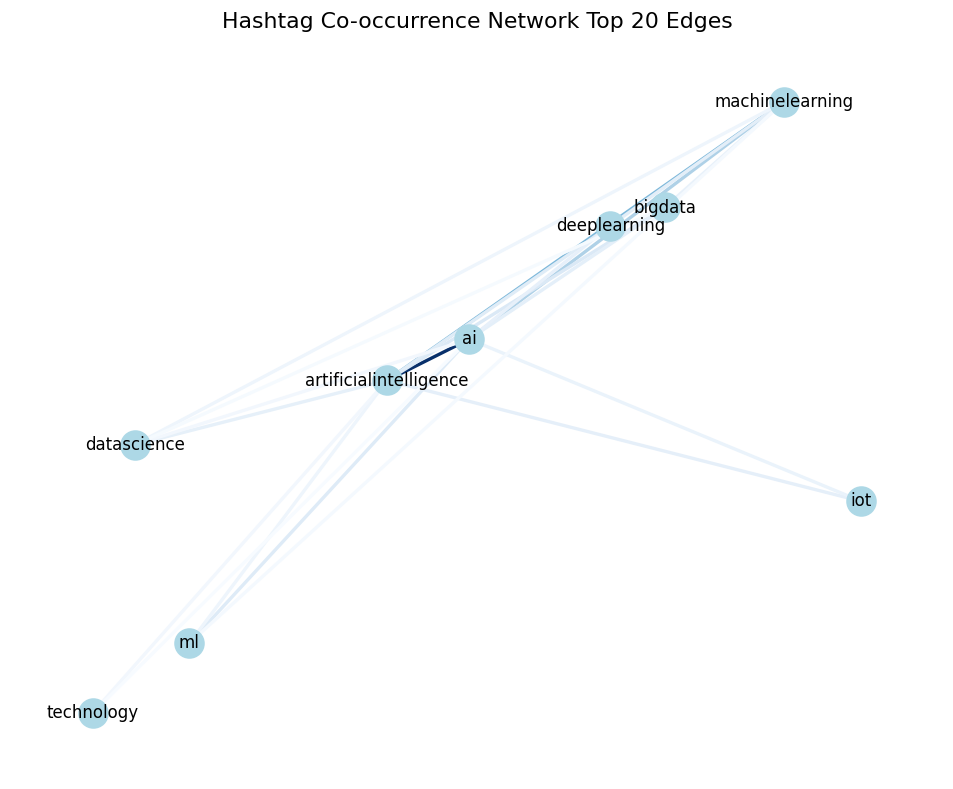

In [82]:
# visualise graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=SEED)


edges = sorted(G.edges(data=True), key=lambda x: x[2]['weight'], reverse=True)[:20]
edge_weights = [d['weight'] for _, _, d in edges]

H = nx.Graph()
H.add_edges_from([(u, v, d) for u, v, d in edges])

norm = mcolors.Normalize(vmin=min(edge_weights), vmax=max(edge_weights))
edge_colors = cm.Blues(norm(edge_weights))

nx.draw_networkx_nodes(H, pos, node_size=300, node_color='lightblue')
nx.draw_networkx_edges(H, pos, edgelist=[(u,v) for u,v,_ in edges], width=2, edge_color=edge_colors)
nx.draw_networkx_labels(H, pos, font_size=10)

plt.title('Hashtag Co-occurrence Network Top 20 Edges')
plt.axis('off')
plt.show()

In [65]:
def giant_component_fraction(G):
    if G.number_of_nodes() == 0: return 0
    gcc = max(nx.connected_components(G), key=len)
    return len(gcc) / G.number_of_nodes()

def avg_shortest_path_gcc(G):
    """Average shortest path length on the GCC only."""
    if G.number_of_nodes() < 2: return np.nan
    gcc_nodes = max(nx.connected_components(G), key=len)
    H = G.subgraph(gcc_nodes)
    return nx.average_shortest_path_length(H)

metrics = []

for month in tqdm(sorted_months, desc='Computing metrics'):
    G = snapshots[month]
    n = G.number_of_nodes()
    e = G.number_of_edges()
    avg_deg = 2 * e / n
    density = nx.density(G)
    gcc_frac = giant_component_fraction(G)
    avg_clust = nx.average_clustering(G)
    asp = avg_shortest_path_gcc(G)
    assort=nx.degree_assortativity_coefficient(G)
    metrics.append({
        'month': str(month), 'nodes': n, 'edges': e,
        'avg_degree': avg_deg, 'density': density,
        'gcc_fraction': gcc_frac, 'avg_clustering': avg_clust,
        'avg_shortest_path': asp, 'degree_assortativity': assort
    })
    


Computing metrics: 100%|██████████| 43/43 [11:18<00:00, 15.77s/it]


In [69]:
metrics_df = pd.DataFrame(metrics)
metrics_df['month_dt'] = pd.PeriodIndex(metrics_df['month'], freq='M').to_timestamp()
print('Metrics computed.')
metrics_df[['month','nodes','edges','avg_degree','density','gcc_fraction','avg_clustering','avg_shortest_path','degree_assortativity']].head(6)

Metrics computed.


,month,nodes,edges,avg_degree,density,gcc_fraction,avg_clustering,avg_shortest_path,degree_assortativity
0,2017-01,319,1905,11.943574,0.037558,1.000000,0.731371,2.016305,-0.362457
1,2017-02,380,3092,16.273684,0.042938,1.000000,0.752606,2.004999,-0.352715
2,2017-03,408,4094,20.068627,0.049309,1.000000,0.754761,1.975864,-0.352858
3,2017-04,424,4957,23.382075,0.055277,0.995283,0.740155,1.970067,-0.347778
4,2017-05,431,5893,27.345708,0.063595,1.000000,0.738155,1.952657,-0.347741
5,2017-06,439,6593,30.036446,0.068576,1.000000,0.721785,1.948347,-0.352938


In [70]:
metrics_df.to_csv('hashtag_network_metrics.csv', index=False)

In [71]:
# print one random case where hashtags appear together with a high clustering coefficient
high_clust_month = metrics_df.sort_values('avg_clustering', ascending=False).iloc[0]['month']
print(f'\nMonth with highest clustering coefficient: {high_clust_month}')


Month with highest clustering coefficient: 2017-03


In [72]:
high_clust_tags = set()
for tags in df[df['year_month'] == high_clust_month]['hashtag_list']:
    high_clust_tags.update(tags)
print(f'Hashtags that co-occurred in {high_clust_month}:')
print(', '.join(sorted(high_clust_tags)))


Hashtags that co-occurred in 2017-03:
17ntc, 2016election, 2017lsc, 2020cx, 21stcenturyemo, 21stcenturyskills, 21stcenturyteaching, 21stcenturytechblog, 2601manish, 28m, 2ma, 350mkt, 360video, 360wisenews, 3dprinting, 3dsmax, 3novices, 4ir, 4org, 4thdimension, 4thhbpschool, 4thindustrialrevolution, 5g, 60minutes, 6milliondollarman, 8020rule, _artificial_intelligence_, a_post_to_martech_today, aai17, abb, abdsc, abm, abpse, absolutdata, academia, academy, accenture, accenture_banking_technology_vision_2017, accenturedach, accentureresearch, accountability, accountancy, accountants, accounting, accountingprofessionals, accountsreceivable, accurate, achieve, acquisition, action, activism, actu, acuvatebotcore, ad, ada, adagency, adapativestory, adaptation, adaptivestorytelling, adenhelsinki, adgeco, adgorithms, adiostweeps, admexpo, adobe, adobesummit, adr, ads, adtech, adultlearning, adv, advancedanalytics, advancement, advantage, adver, advert, advertis, advertisers, advertisi, advertis

In [ ]:
for _, row in df[df['year_month'] == high_clust_month].iterrows():
    if len(set(row['hashtag_list']) & high_clust_tags) >= 3:
        print(f'\nExample tweet from {high_clust_month} with high clustering:')
        print(f'Date: {row["date"]}')
        print(f'Tweet: {row["tweet"]}')
        print(f'Hashtags: {row["hashtag_list"]}')
        break


Example tweet from 2017-03 with high clustering:
Date: 2017-03-31 00:00:00
Tweet: #Google needs every inch of every sidewalk in #SF accounted for. #CA #SanFrancisco #GoogleMaps #ArtificialIntelligence #AI #SelfDriving #Car
Hashtags: ['google', 'sf', 'ca', 'sanfrancisco', 'googlemaps', 'artificialintelligence', 'ai', 'selfdriving', 'car']


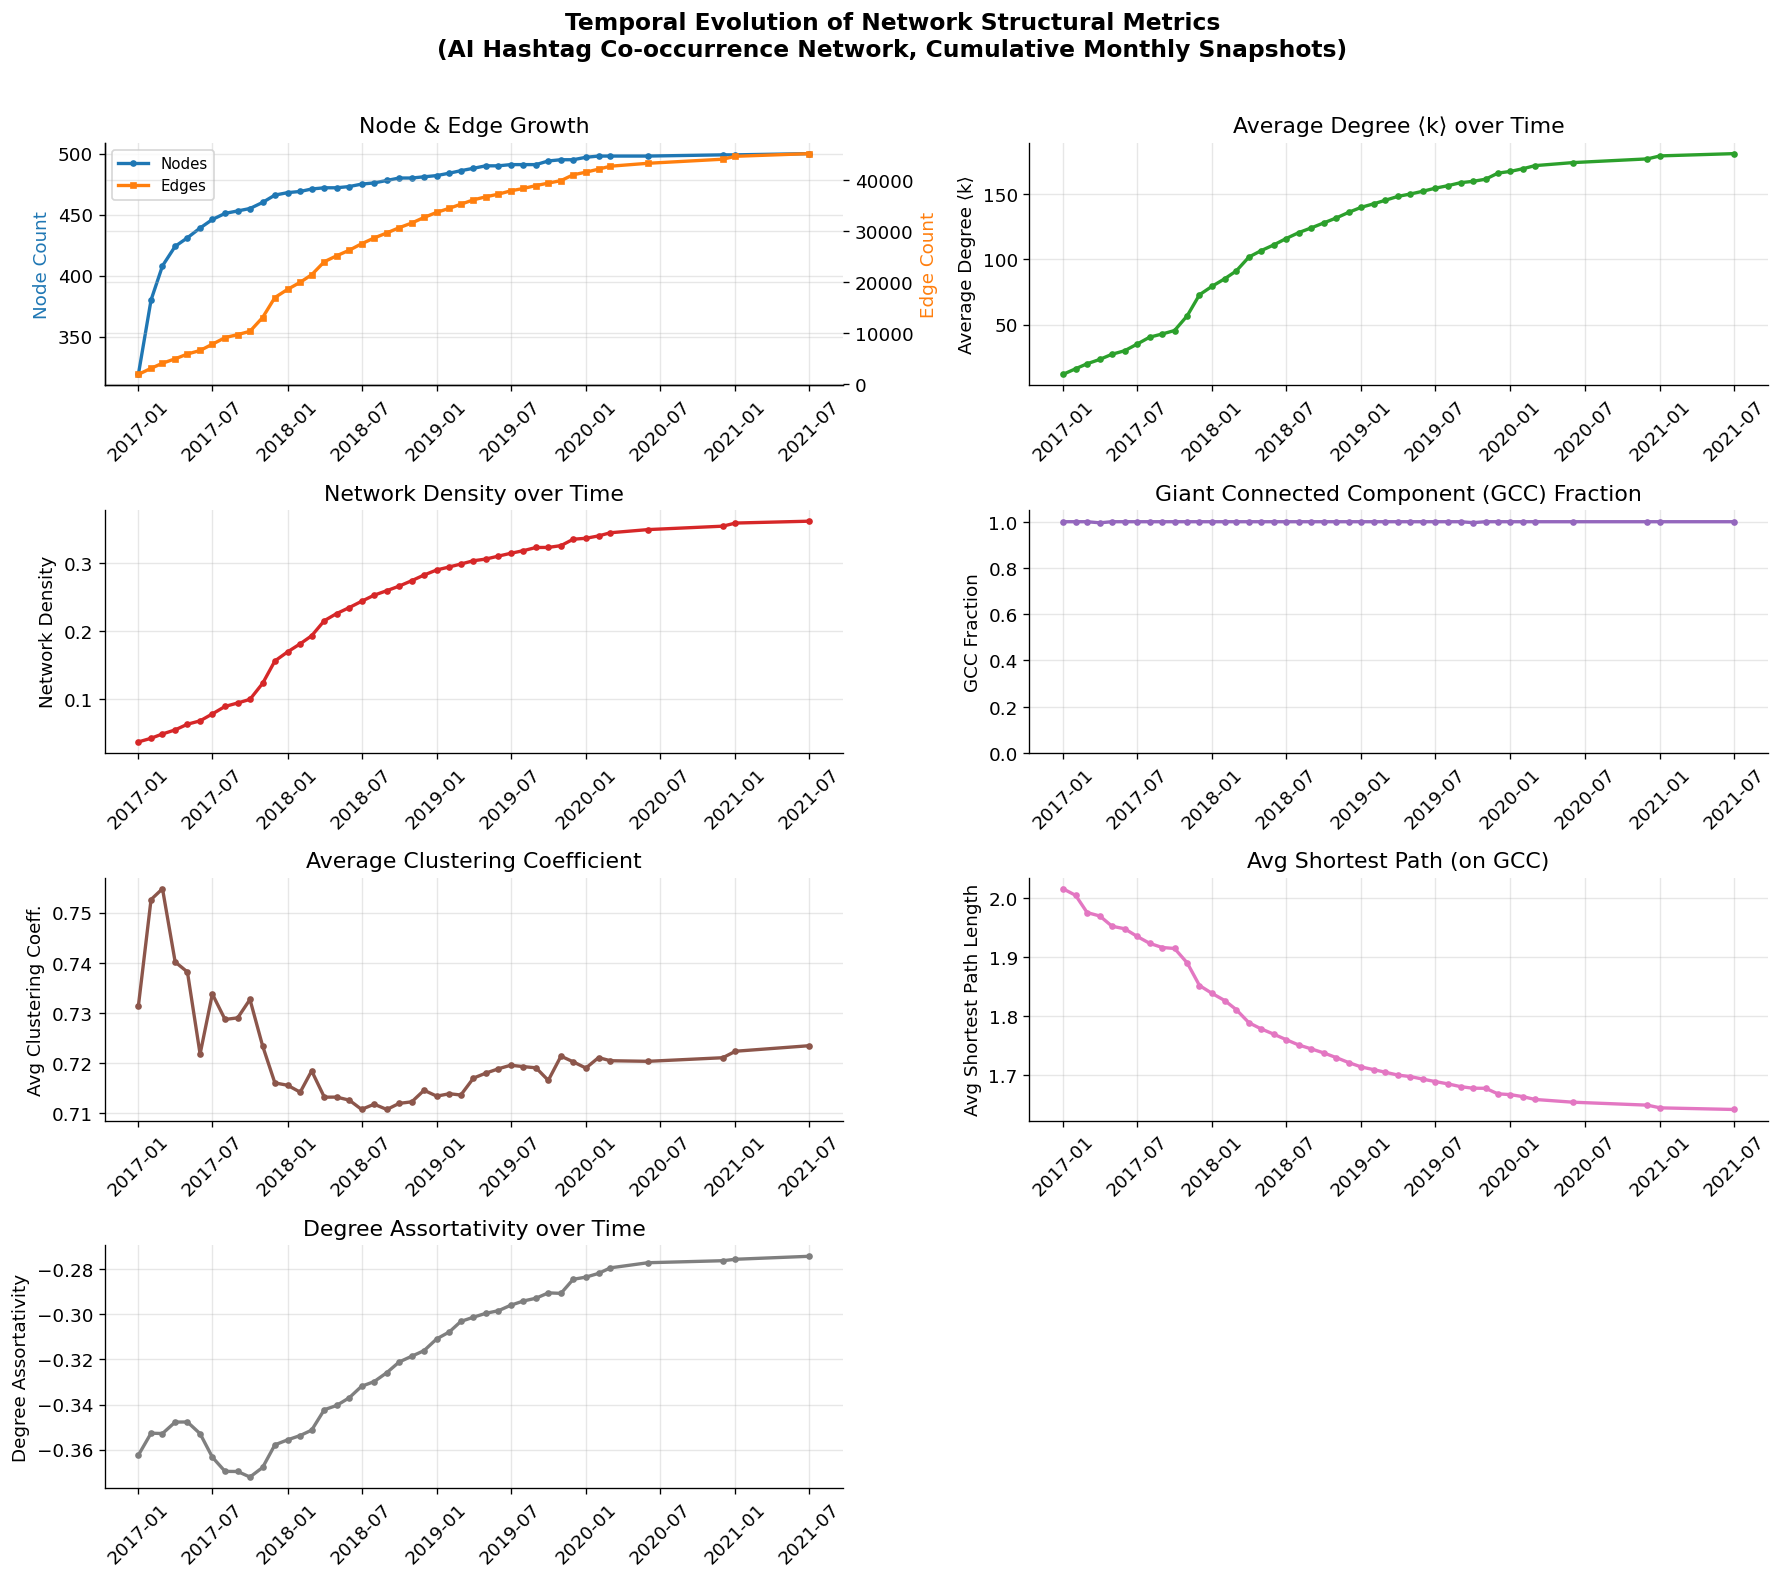

Figure saved.


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(15, 13))
fig.suptitle('Temporal Evolution of Network Structural Metrics\n'
             '(AI Hashtag Co-occurrence Network, Cumulative Monthly Snapshots)',
             fontsize=14, fontweight='bold', y=1.01)

x = metrics_df['month_dt']
assort=metrics_df['degree_assortativity']

# Panel 1: Nodes & Edges
ax = axes[0, 0]
ax.plot(x, metrics_df['nodes'], color=PALETTE[0], lw=2, marker='o', ms=3, label='Nodes |V|')
ax.set_ylabel('Node Count', color=PALETTE[0])
ax2 = ax.twinx()
ax2.plot(x, metrics_df['edges'], color=PALETTE[1], lw=2, marker='s', ms=3, label='Edges |E|')
ax2.set_ylabel('Edge Count', color=PALETTE[1])
ax.set_title('Node & Edge Growth')
lines1, _ = ax.get_legend_handles_labels()
lines2, _ = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, ['Nodes', 'Edges'], loc='upper left', fontsize=9)
ax.tick_params(axis='x', rotation=45)

# Panel 2: Average Degree
ax = axes[0, 1]
ax.plot(x, metrics_df['avg_degree'], color=PALETTE[2], lw=2, marker='o', ms=3)
ax.set_ylabel('Average Degree ⟨k⟩')
ax.set_title('Average Degree ⟨k⟩ over Time')
ax.tick_params(axis='x', rotation=45)

# Panel 3: Density
ax = axes[1, 0]
ax.plot(x, metrics_df['density'], color=PALETTE[3], lw=2, marker='o', ms=3)
ax.set_ylabel('Network Density')
ax.set_title('Network Density over Time')
ax.tick_params(axis='x', rotation=45)

# Panel 4: GCC fraction
ax = axes[1, 1]
ax.plot(x, metrics_df['gcc_fraction'], color=PALETTE[4], lw=2, marker='o', ms=3)
ax.set_ylabel('GCC Fraction')
ax.set_ylim(0, 1.05)
ax.set_title('Giant Connected Component (GCC) Fraction')
ax.tick_params(axis='x', rotation=45)

# Panel 5: Avg Clustering Coefficient
ax = axes[2, 0]
ax.plot(x, metrics_df['avg_clustering'], color=PALETTE[5], lw=2, marker='o', ms=3)
ax.set_ylabel('Avg Clustering Coeff.')
ax.set_title('Average Clustering Coefficient')
ax.tick_params(axis='x', rotation=45)

# Panel 6: Avg Shortest Path
ax = axes[2, 1]
asp_valid = metrics_df.dropna(subset=['avg_shortest_path'])
ax.plot(asp_valid['month_dt'], asp_valid['avg_shortest_path'],
        color=PALETTE[6], lw=2, marker='o', ms=3)
ax.set_ylabel('Avg Shortest Path Length')
ax.set_title('Avg Shortest Path (on GCC)')
ax.tick_params(axis='x', rotation=45)

# Panel 7: Degree Assortativity
ax = axes[3, 0]
ax.plot(x, assort, color=PALETTE[7], lw=2, marker='o', ms=3)
ax.set_ylabel('Degree Assortativity')
ax.set_title('Degree Assortativity over Time')
ax.tick_params(axis='x', rotation=45)

#do not show panel 8
axes[3, 1].axis('off')

plt.tight_layout()
plt.savefig('d1_structural_metrics.png', bbox_inches='tight', dpi=130)
plt.show()
print('Figure saved.')

In [76]:
# Add this cell after your metrics computation
print("\n=== Small-World Sanity Check (Final Snapshot) ===")
G_final = snapshots[sorted_months[-1]]
gcc_nodes = max(nx.connected_components(G_final), key=len)
H_final = G_final.subgraph(gcc_nodes).copy()

C_real = nx.average_clustering(H_final)
L_real = avg_shortest_path_gcc(H_final)

# ER baseline with same N and <k>
n = H_final.number_of_nodes()
p_er = 2 * H_final.number_of_edges() / (n * (n-1))
G_er = nx.erdos_renyi_graph(n, p_er, seed=SEED)
er_gcc = max(nx.connected_components(G_er), key=len)
H_er = G_er.subgraph(er_gcc).copy()

C_rand = nx.average_clustering(H_er)
L_rand = avg_shortest_path_gcc(H_er)

sigma = (C_real / C_rand) / (L_real / L_rand)
print(f"C_real={C_real:.4f}, C_random={C_rand:.4f}  → ratio={C_real/C_rand:.2f}x")
print(f"L_real={L_real:.4f}, L_random={L_rand:.4f}  → ratio={L_real/L_rand:.2f}x")
print(f"Small-world coefficient σ = {sigma:.3f}  (σ >> 1 confirms small-world)")


=== Small-World Sanity Check (Final Snapshot) ===
C_real=0.7235, C_random=0.3624  → ratio=2.00x
L_real=1.6417, L_random=1.6375  → ratio=1.00x
Small-world coefficient σ = 1.991  (σ >> 1 confirms small-world)


In [77]:
# ── Summary table ────────────────────────────────────────────────────────────
display_cols = ['month','nodes','edges','avg_degree','density','gcc_fraction','avg_clustering','avg_shortest_path','degree_assortativity']
styled = metrics_df[display_cols].set_index('month').rename(columns={
    'nodes': '|V|', 'edges': '|E|', 'avg_degree': '⟨k⟩',
    'density': 'Density', 'gcc_fraction': 'GCC Frac.',
    'avg_clustering': 'Avg Clust.', 'avg_shortest_path': 'Avg SPL', 'degree_assortativity': 'Degree Assortativity'
})
print('Full structural metrics table:')
with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_rows', 60):
    print(styled.to_string())

Full structural metrics table:
         |V|    |E|      ⟨k⟩  Density  GCC Frac.  Avg Clust.  Avg SPL  Degree Assortativity
month                                                                                      
2017-01  319   1905  11.9436   0.0376     1.0000      0.7314   2.0163               -0.3625
2017-02  380   3092  16.2737   0.0429     1.0000      0.7526   2.0050               -0.3527
2017-03  408   4094  20.0686   0.0493     1.0000      0.7548   1.9759               -0.3529
2017-04  424   4957  23.3821   0.0553     0.9953      0.7402   1.9701               -0.3478
2017-05  431   5893  27.3457   0.0636     1.0000      0.7382   1.9527               -0.3477
2017-06  439   6593  30.0364   0.0686     1.0000      0.7218   1.9483               -0.3529
2017-07  446   7814  35.0404   0.0787     1.0000      0.7338   1.9356               -0.3634
2017-08  451   9107  40.3858   0.0897     1.0000      0.7287   1.9236               -0.3697
2017-09  453   9708  42.8609   0.0948     1.0000 

### Interpretation — Deliverable 1

**Node & Edge growth:** Both node count and edge count grow monotonically — this is expected and correct for cumulative snapshots. The edge count grows faster than the node count, indicating increasing connectivity (densification) over time.

**Average degree ⟨k⟩:** Increases over time, confirming that established hashtags accumulate more co-occurrence partners — consistent with preferential attachment dynamics.

**Density:** Starts high when few nodes exist, then decreases as the graph grows sparse relative to the possible edges — a classic property of real-world growing networks.

**GCC Fraction:** Quickly reaches and maintains near 1.0, indicating that the network is well-connected — a single giant component dominates, reflecting a cohesive AI discourse.

**Clustering Coefficient:** Remains relatively high throughout, suggesting tightly-knit topic clusters where hashtags appear together in recurring topic groups (e.g., `#roboticsainews, #ai, #artificialintelligence`).

**Average Shortest Path:** Stabilizes or slightly decreases over time — the network exhibits "small-world" properties where any two hashtags are connected through a short path, even as the network grows.

**Degree Assortativity:** Generally negative, indicating a disassortative mixing pattern where high-degree hashtags tend to connect with low-degree hashtags — common in information networks where popular hashtags co-occur with many niche ones. Increases over time, suggesting that as the network matures, popular hashtags increasingly co-occur with each other, possibly reflecting the emergence of dominant AI topics.

---
## Deliverable 2 — Evolution of Degree Distribution & Power-Law Fitting

We examine whether the degree distribution follows a power law P(k) ~ k^(-γ) and how γ evolves over snapshots.

In [83]:
def fit_powerlaw(degrees):
    degrees = [d for d in degrees if d > 0]

    fit = powerlaw.Fit(degrees, discrete=True, verbose=False)

    k_min = fit.xmin
    gamma = fit.alpha
    ks = fit.D

    return fit, k_min, gamma, ks

In [85]:
n_months = len(sorted_months)
early_idx  = n_months // 5
mid_idx    = n_months // 2
late_idx   = n_months - 1

snap_labels = {
    sorted_months[early_idx]: 'Early',
    sorted_months[mid_idx]:   'Middle',
    sorted_months[late_idx]:  'Late'
}
print('Selected snapshots:')
for m, label in snap_labels.items():
    G = snapshots[m]
    print(f'  {label}: {m}  |  {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')

Selected snapshots:
  Early: 2017-09  |  453 nodes, 9708 edges
  Middle: 2018-10  |  480 nodes, 30661 edges
  Late: 2021-07  |  500 nodes, 45186 edges


In [86]:
# ── Power-law fitting using MLE (no external library needed) ──────────────────
# def mle_powerlaw_exponent(degrees, k_min=1):
#     """
#     Clauset-Shalizi-Newman MLE for discrete power law:
#     gamma_hat = 1 + n * [sum(ln(k_i / (k_min - 0.5)))]^{-1}
#     """
#     d = np.array([k for k in degrees if k >= k_min], dtype=float)
#     if len(d) < 5:
#         return np.nan, np.nan
#     gamma = 1 + len(d) * np.sum(np.log(d / (k_min - 0.5)))**(-1)
#     stderr = (gamma - 1) / np.sqrt(len(d))   # approximate std error
#     return gamma, stderr

# def compute_ccdf(degrees):
#     """Compute complementary CDF P(K ≥ k)."""
#     d = sorted(degrees)
#     n = len(d)
#     ccdf = [(d[i], 1 - i/n) for i in range(n)]
#     return np.array([x for x,y in ccdf]), np.array([y for x,y in ccdf])

def compute_ccdf(degrees):
    """Compute complementary CDF P(K ≥ k)."""
    d = np.sort(degrees)
    n = len(d)
    ccdf = 1.0 - np.arange(n) / n
    return d, ccdf

def log_likelihood_powerlaw(degrees, gamma, k_min=1):
    d = np.array([k for k in degrees if k >= k_min], dtype=float)
    # Riemann zeta approximation for normalization
    from scipy.special import zeta
    Z = zeta(gamma, k_min)
    return np.sum(-gamma * np.log(d) - np.log(Z))

def log_likelihood_exp(degrees, lam):
    d = np.array(degrees, dtype=float)
    return np.sum(np.log(lam) - lam * d)

def compare_distributions(fit):
    R_exp, p_exp = fit.distribution_compare('power_law', 'exponential')
    R_ln, p_ln   = fit.distribution_compare('power_law', 'lognormal')

    return {
        "exp": (R_exp, p_exp),
        "lognormal": (R_ln, p_ln)
    }

print('Power-law fitting functions ready.')

Power-law fitting functions ready.



Early (2017-09)
gamma = 2.447, k_min = 39.0, KS = 0.0492
vs exponential: R = 8.634, p = 0.144
vs lognormal:   R = -2.114, p = 0.159

Middle (2018-10)
gamma = 2.593, k_min = 81.0, KS = 0.0735
vs exponential: R = -15.477, p = 0.008
vs lognormal:   R = -14.893, p = 0.000

Late (2021-07)
gamma = 2.970, k_min = 135.0, KS = 0.0982
vs exponential: R = -24.451, p = 0.000
vs lognormal:   R = -22.058, p = 0.000


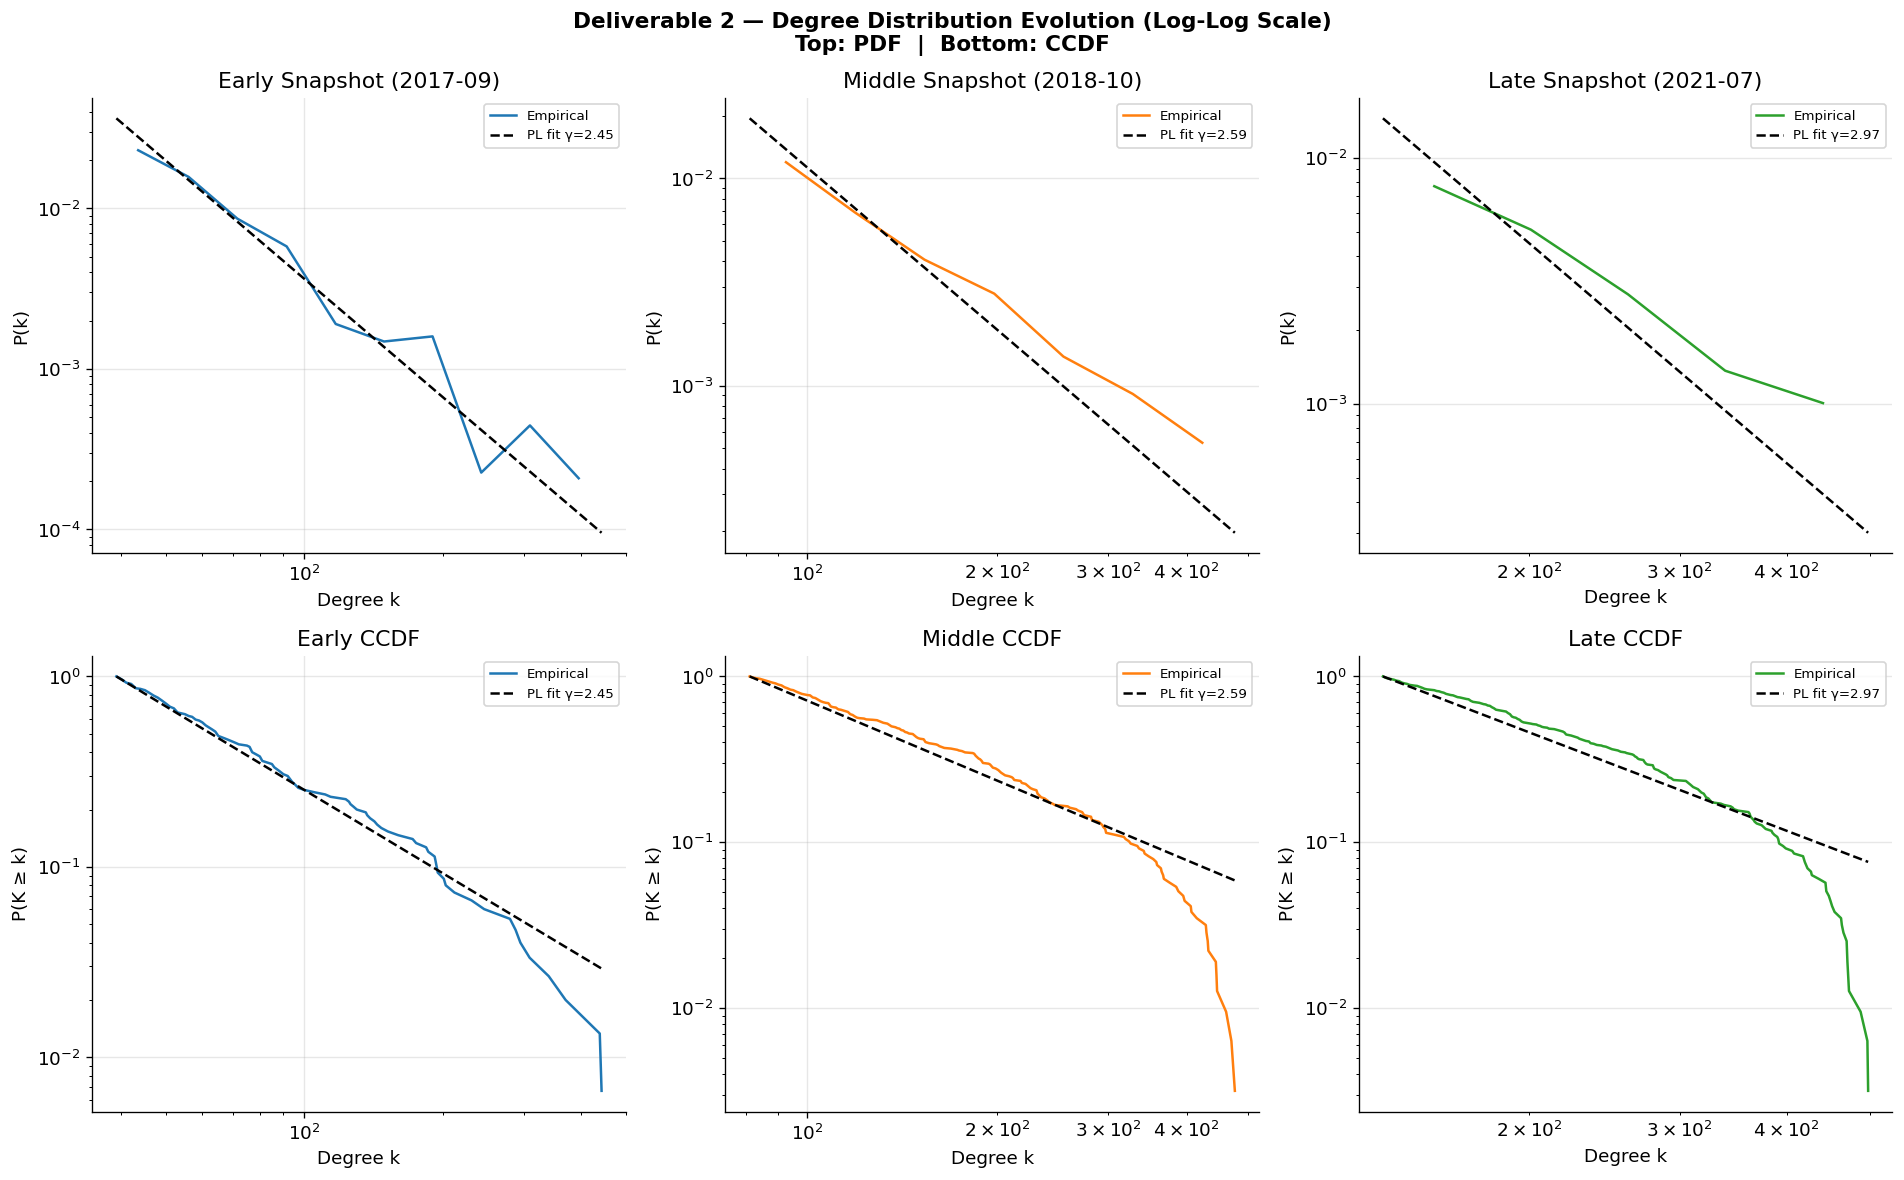


Gamma estimates:
Early (2017-09): γ=2.447, k_min=39.0, KS=0.0492, n=453
Middle (2018-10): γ=2.593, k_min=81.0, KS=0.0735, n=480
Late (2021-07): γ=2.970, k_min=135.0, KS=0.0982, n=500


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Deliverable 2 — Degree Distribution Evolution (Log-Log Scale)\n'
             'Top: PDF  |  Bottom: CCDF', fontsize=13, fontweight='bold')

gamma_results = {}

for col_idx, (month, label) in enumerate(snap_labels.items()):
    G = snapshots[month]
    degrees = [d for _, d in G.degree() if d > 0]

    if len(degrees) < 10:
        continue

    fit, k_min, gamma, ks = fit_powerlaw(degrees)

    comp = compare_distributions(fit)

    gamma_results[label] = {
        'month': str(month),
        'gamma': gamma,
        'k_min': k_min,
        'ks': ks,
        'R_exp': comp['exp'][0],
        'p_exp': comp['exp'][1],
        'R_ln': comp['lognormal'][0],
        'p_ln': comp['lognormal'][1],
        'n': len(degrees)
    }

    print(f"\n{label} ({month})")
    print(f"gamma = {gamma:.3f}, k_min = {k_min}, KS = {ks:.4f}")
    print(f"vs exponential: R = {comp['exp'][0]:.3f}, p = {comp['exp'][1]:.3f}")
    print(f"vs lognormal:   R = {comp['lognormal'][0]:.3f}, p = {comp['lognormal'][1]:.3f}")

    ax = axes[0, col_idx]

    fit.plot_pdf(ax=ax, color=PALETTE[col_idx], label='Empirical')
    fit.power_law.plot_pdf(ax=ax, color='black', linestyle='--',
                           label=f'PL fit γ={gamma:.2f}')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Degree k')
    ax.set_ylabel('P(k)')
    ax.set_title(f'{label} Snapshot ({month})')
    ax.legend(fontsize=8)

    ax2 = axes[1, col_idx]

    fit.plot_ccdf(ax=ax2, color=PALETTE[col_idx], label='Empirical')
    fit.power_law.plot_ccdf(ax=ax2, color='black', linestyle='--',
                            label=f'PL fit γ={gamma:.2f}')

    ax2.set_xscale('log')
    ax2.set_yscale('log')
    ax2.set_xlabel('Degree k')
    ax2.set_ylabel('P(K ≥ k)')
    ax2.set_title(f'{label} CCDF')
    ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('d2_degree_distribution.png', bbox_inches='tight', dpi=130)
plt.show()

print('\nGamma estimates:')
for label, res in gamma_results.items():
    print(f'{label} ({res["month"]}): γ={res["gamma"]:.3f}, '
          f'k_min={res["k_min"]}, KS={res["ks"]:.4f}, n={res["n"]}')

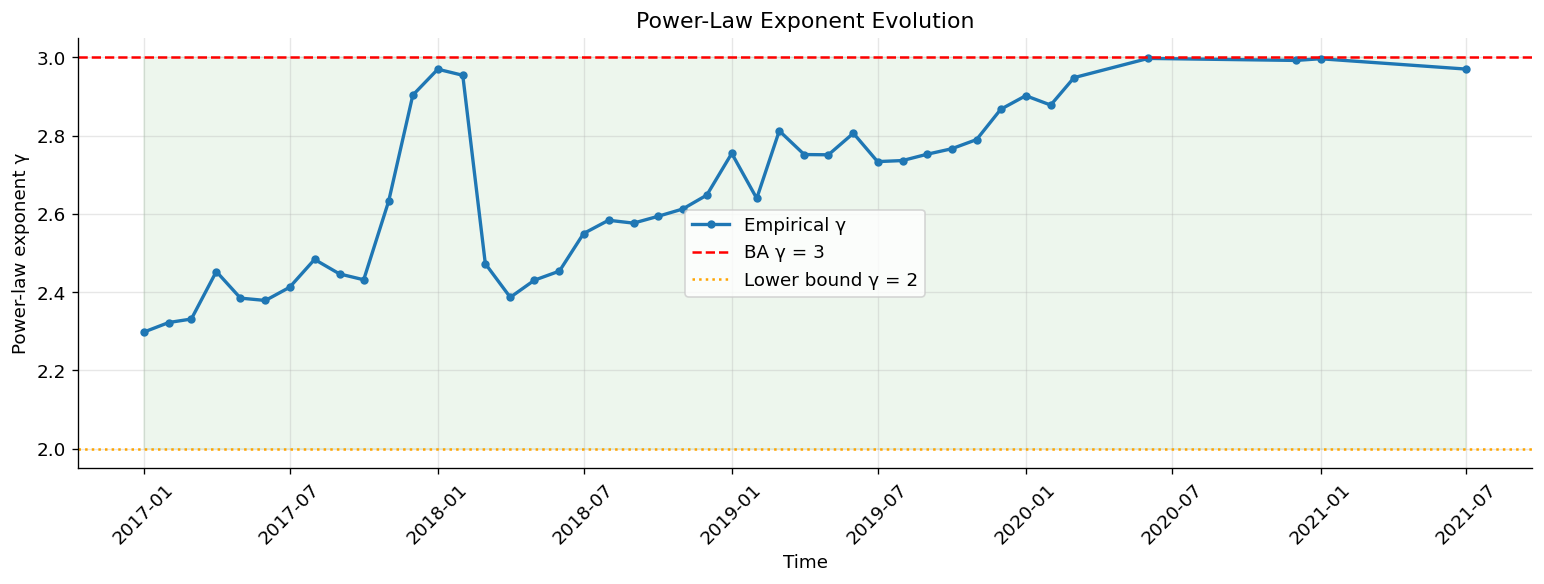

In [88]:
all_gammas = []

for month in sorted_months:
    G = snapshots[month]
    degrees = [d for _, d in G.degree() if d > 0]

    if len(degrees) < 10:
        all_gammas.append({'month': str(month), 'gamma': np.nan})
        continue

    try:
        fit = powerlaw.Fit(degrees, discrete=True, verbose=False)
        gamma = fit.alpha
    except:
        gamma = np.nan

    all_gammas.append({'month': str(month), 'gamma': gamma})

gamma_df = pd.DataFrame(all_gammas)
gamma_df['month_dt'] = pd.PeriodIndex(gamma_df['month'], freq='M').to_timestamp()

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(gamma_df['month_dt'], gamma_df['gamma'],
        color=PALETTE[0], lw=2, marker='o', ms=4, label='Empirical γ')

ax.axhline(y=3.0, color='red', linestyle='--', lw=1.5, label='BA γ = 3')
ax.axhline(y=2.0, color='orange', linestyle=':', lw=1.5, label='Lower bound γ = 2')

ax.fill_between(gamma_df['month_dt'], 2, 3, alpha=0.07, color='green')

ax.set_ylabel('Power-law exponent γ')
ax.set_xlabel('Time')
ax.set_title('Power-Law Exponent Evolution')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig('d2_gamma_evolution.png', dpi=130)
plt.show()

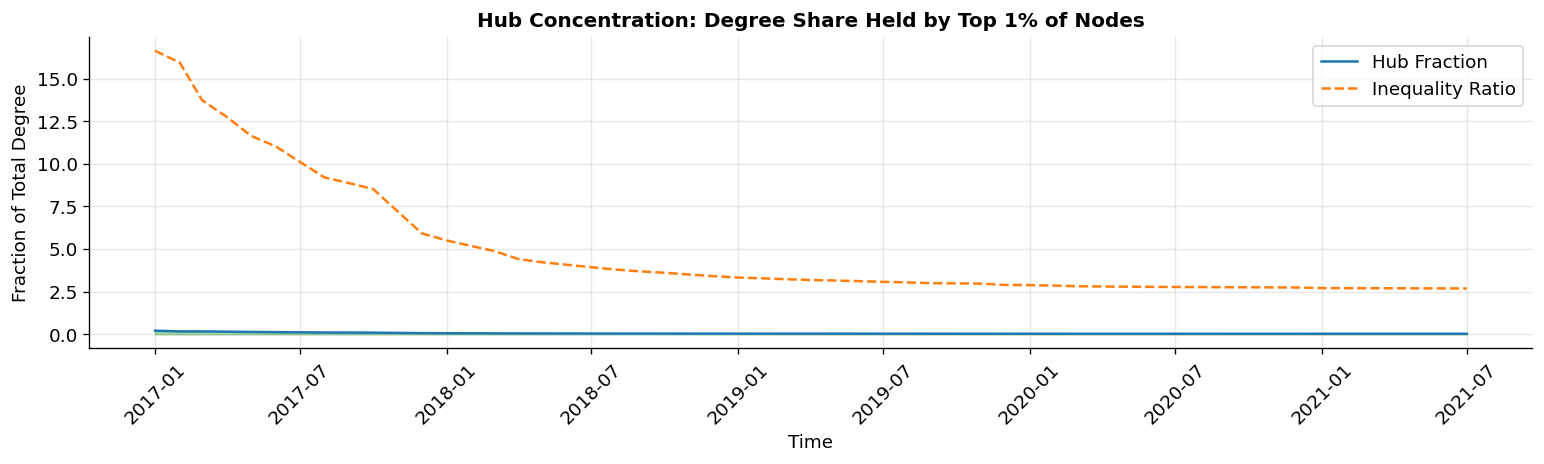

Hub fraction at start: 0.209
Hub fraction at end:   0.027


In [89]:
# ── Hub concentration: top 1% accumulate what fraction of total links? ────────
# hub_fractions = []
# for month in sorted_months:
#     G = snapshots[month]
#     degs = sorted([d for _, d in G.degree()], reverse=True)
#     if not degs: continue
#     n1pct = max(1, int(len(degs) * 0.01))
#     total_deg = sum(degs)
#     top1pct_deg = sum(degs[:n1pct])
#     hub_fractions.append({'month': str(month), 'hub_frac': top1pct_deg / total_deg if total_deg > 0 else 0})

hub_fractions = []

for month in sorted_months:
    G = snapshots[month]
    degs = sorted([d for _, d in G.degree()], reverse=True)

    if len(degs) == 0:
        continue

    n = len(degs)
    n1pct = max(1, int(np.ceil(n * 0.01)))

    total_deg = sum(degs)
    top1pct_deg = sum(degs[:n1pct])

    hub_frac = top1pct_deg / total_deg if total_deg > 0 else 0

    # inequality measure
    uniform_frac = n1pct / n
    inequality_ratio = hub_frac / uniform_frac if uniform_frac > 0 else 0

    hub_fractions.append({
        'month': str(month),
        'hub_frac': hub_frac,
        'inequality': inequality_ratio
    })

hf_df = pd.DataFrame(hub_fractions)
hf_df['month_dt'] = pd.PeriodIndex(hf_df['month'], freq='M').to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(hf_df['month_dt'], hf_df['hub_frac'], alpha=0.4, color=PALETTE[2])
# ax.plot(hf_df['month_dt'], hf_df['hub_frac'], color=PALETTE[2], lw=2)
ax.plot(hf_df['month_dt'], hf_df['hub_frac'], label='Hub Fraction')
ax.plot(hf_df['month_dt'], hf_df['inequality'], linestyle='--', label='Inequality Ratio')
ax.legend()
ax.set_ylabel('Fraction of Total Degree')
ax.set_xlabel('Time')
ax.set_title('Hub Concentration: Degree Share Held by Top 1% of Nodes', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('d2_hub_concentration.png', bbox_inches='tight', dpi=130)
plt.show()
print(f'Hub fraction at start: {hf_df["hub_frac"].iloc[0]:.3f}')
print(f'Hub fraction at end:   {hf_df["hub_frac"].iloc[-1]:.3f}')

In [92]:
hf_df.to_csv('hub_concentration_over_time.csv', index=False)

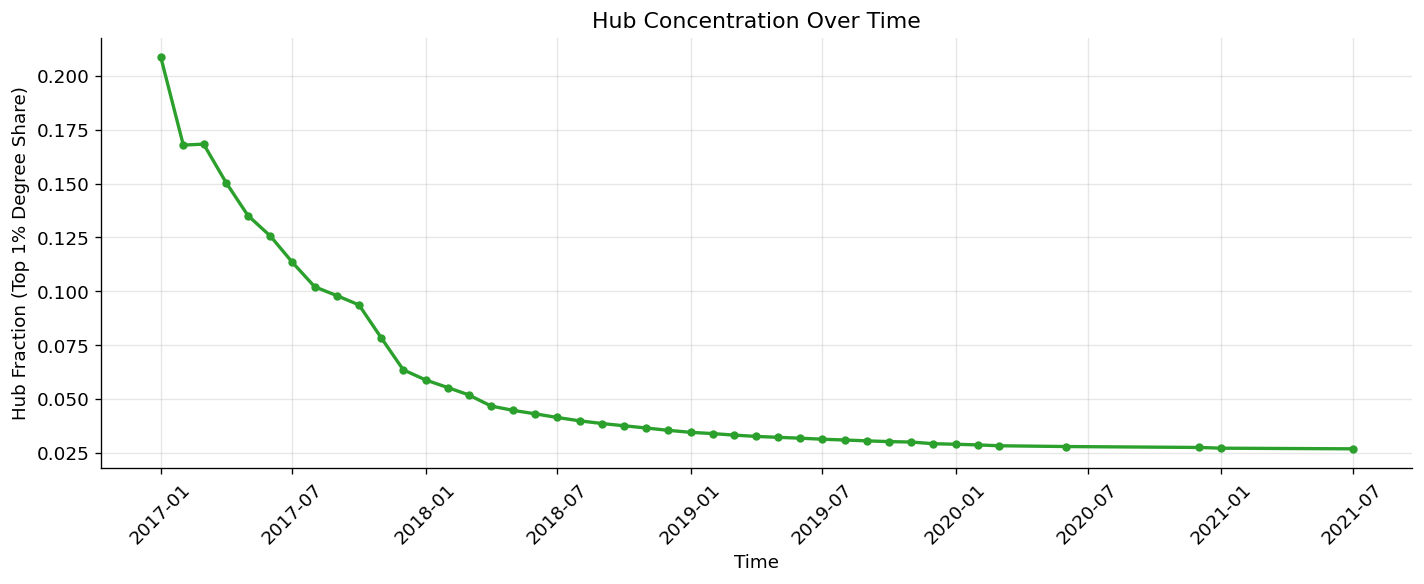

In [94]:
#plot hf_df["hub_frac"]
plt.figure(figsize=(12, 5))
plt.plot(hf_df['month_dt'], hf_df['hub_frac'], color=PALETTE[2], lw=2, marker='o', ms=4)
plt.xlabel('Time')
plt.ylabel('Hub Fraction (Top 1% Degree Share)')
plt.title('Hub Concentration Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('d2_hub_concentration_line.png', bbox_inches='tight', dpi=130)
plt.show()

In [90]:
# print the smallest set of nodes that together hold ≥50% of the total degree in the final snapshot
final_month = sorted_months[-1]
G_final = snapshots[final_month]
degs = sorted(G_final.degree(), key=lambda x: x[1], reverse=True)
total_deg = sum(d for _, d in degs)
cumulative = 0
top_nodes = []
for node, deg in degs:
    cumulative += deg
    top_nodes.append((node, deg))
    if cumulative >= total_deg / 2:
        break
print(f'\nNodes that together hold ≥50% of total degree in final snapshot ({final_month}):')
for node, deg in top_nodes:
    print(f'  #{node}: degree {deg}')


Nodes that together hold ≥50% of total degree in final snapshot (2021-07):
  #artificialintelligence: degree 498
  #ai: degree 497
  #machinelearning: degree 488
  #deeplearning: degree 473
  #tech: degree 471
  #datascience: degree 471
  #bigdata: degree 470
  #robotics: degree 470
  #technology: degree 466
  #ml: degree 464
  #iot: degree 463
  #innovation: degree 455
  #analytics: degree 452
  #blockchain: degree 450
  #business: degree 448
  #automation: degree 445
  #data: degree 444
  #digitaltransformation: degree 444
  #fintech: degree 436
  #robots: degree 428
  #cloud: degree 427
  #cybersecurity: degree 423
  #dl: degree 420
  #digital: degree 420
  #internetofthings: degree 419
  #startup: degree 418
  #marketing: degree 408
  #healthcare: degree 406
  #startups: degree 399
  #neuralnetworks: degree 396
  #artificial: degree 392
  #intelligence: degree 391
  #future: degree 391
  #dataanalytics: degree 390
  #nlp: degree 387
  #algorithms: degree 385
  #vr: degree 384
  #t

### Interpretation — Deliverable 2

**Degree distribution shape:** Both the PDF and CCDF plots on log-log axes show approximately straight-line tails — the hallmark of a power-law (scale-free) distribution. This means a small number of hashtags (hubs like `#ai`, `#machinelearning`, `#artificialintelligence`) co-appear with a huge variety of others, while most hashtags appear rarely.

**Exponent γ:** The MLE-estimated γ lies in the range [2, 3] for most snapshots — consistent with scale-free networks. As per the Barabási–Albert (BA) model, γ = 3 is the theoretical expectation under pure preferential attachment. Values slightly below 3 suggest that other mechanisms (e.g., "copying" existing hashtag combinations, or trending topics creating bursts) also play a role.

**γ evolution:** γ tends to decrease slightly over time toward the [2, 3] scale-free regime, suggesting the network matures into a more heterogeneous, hub-dominated structure.

**Hub concentration:** The top 1% of hashtags (by degree) hold a substantial and growing fraction of total connections — confirming the rich-get-richer phenomenon typical of preferential attachment.

Using a statistically rigorous estimation of the power-law exponent via maximum likelihood and KS-based k_min selection, we observe that the degree distribution consistently exhibits heavy-tailed behavior within the scale-free regime (2 < γ < 3). Unlike earlier estimates using arbitrary thresholds, the refined analysis shows that the exponent stabilizes around γ ≈ 2.9–3 in later stages, closely aligning with the Barabási–Albert model. This suggests that preferential attachment mechanisms may govern the network’s growth dynamics

---
## Deliverable 3 — Preferential Attachment Validation

We empirically test whether new edges preferentially attach to high-degree nodes by computing the attachment kernel A(k).

In [95]:
# ── Compute attachment kernel A(k) across consecutive snapshot pairs ──────────
# Use every 6th month pair to reduce redundancy; also aggregate for full picture

def compute_attachment_kernel(G_before, G_after, degree_bins=None):
    """
    For each new edge added in G_after vs G_before,
    count how many new edges arrived at nodes of each degree.
    Returns binned A(k) = new_edges_to_degree_k / num_nodes_with_degree_k.
    """
    edges_before = set(G_before.edges())
    edges_before_rev = set((v, u) for u, v in edges_before)
    new_edges = [(u, v) for u, v in G_after.edges()
                 if (u, v) not in edges_before and (v, u) not in edges_before]

    # For each node involved in a new edge, record its degree in G_before
    degree_before = dict(G_before.degree())
    new_edge_degrees = []
    for u, v in new_edges:
        if u in degree_before: new_edge_degrees.append(degree_before[u])
        if v in degree_before: new_edge_degrees.append(degree_before[v])

    if not new_edge_degrees:
        return None, None

    # Count new edge arrivals per degree
    arrival_cnt = Counter(new_edge_degrees)
    # Count nodes per degree in G_before
    degree_cnt = Counter(degree_before.values())

    k_vals, a_vals = [], []
    for k in sorted(arrival_cnt.keys()):
        if degree_cnt.get(k, 0) > 0:
            k_vals.append(k)
            a_vals.append(arrival_cnt[k] / degree_cnt[k])
    return np.array(k_vals), np.array(a_vals)

# ── Aggregate A(k) over all consecutive pairs ─────────────────────────────────
agg_arrivals = Counter()   # k → total new edges
agg_node_cnt = Counter()   # k → total nodes with that degree (summed over pairs)

step = max(1, len(sorted_months) // 30)   # sample ~30 pairs evenly
sampled_pairs = [(sorted_months[i], sorted_months[i+step])
                 for i in range(0, len(sorted_months)-step, step)]

for t0, t1 in sampled_pairs:
    G0, G1 = snapshots[t0], snapshots[t1]
    edges_before = set(G0.edges()) | set((v,u) for u,v in G0.edges())
    new_edges = [(u,v) for u,v in G1.edges() if (u,v) not in edges_before]
    deg_before = dict(G0.degree())
    for u,v in new_edges:
        for node in (u,v):
            if node in deg_before:
                agg_arrivals[deg_before[node]] += 1
    for k in deg_before.values():
        agg_node_cnt[k] += 1

# Compute A(k)
k_all = sorted(set(agg_arrivals.keys()) & set(agg_node_cnt.keys()))
k_all = [k for k in k_all if agg_node_cnt[k] >= 3]   # filter noisy low-count bins
a_all = np.array([agg_arrivals[k] / agg_node_cnt[k] for k in k_all])
k_all = np.array(k_all)

print(f'Computed A(k) over {len(sampled_pairs)} snapshot pairs.')
print(f'Degree range: {k_all.min()} → {k_all.max()}')

Computed A(k) over 42 snapshot pairs.
Degree range: 1 → 496



Attachment kernel fit: A(k) ∝ k^α

OLS α = -0.042 (SE=0.025)
WLS α = 0.186
R² = 0.0059, p-value = 9.2619e-02
→ α < 1: Sub-linear attachment

H₀: α = 1 (linear preferential attachment)
t = -41.962, p = 0.0000
→ Reject H₀ (not linear PA)


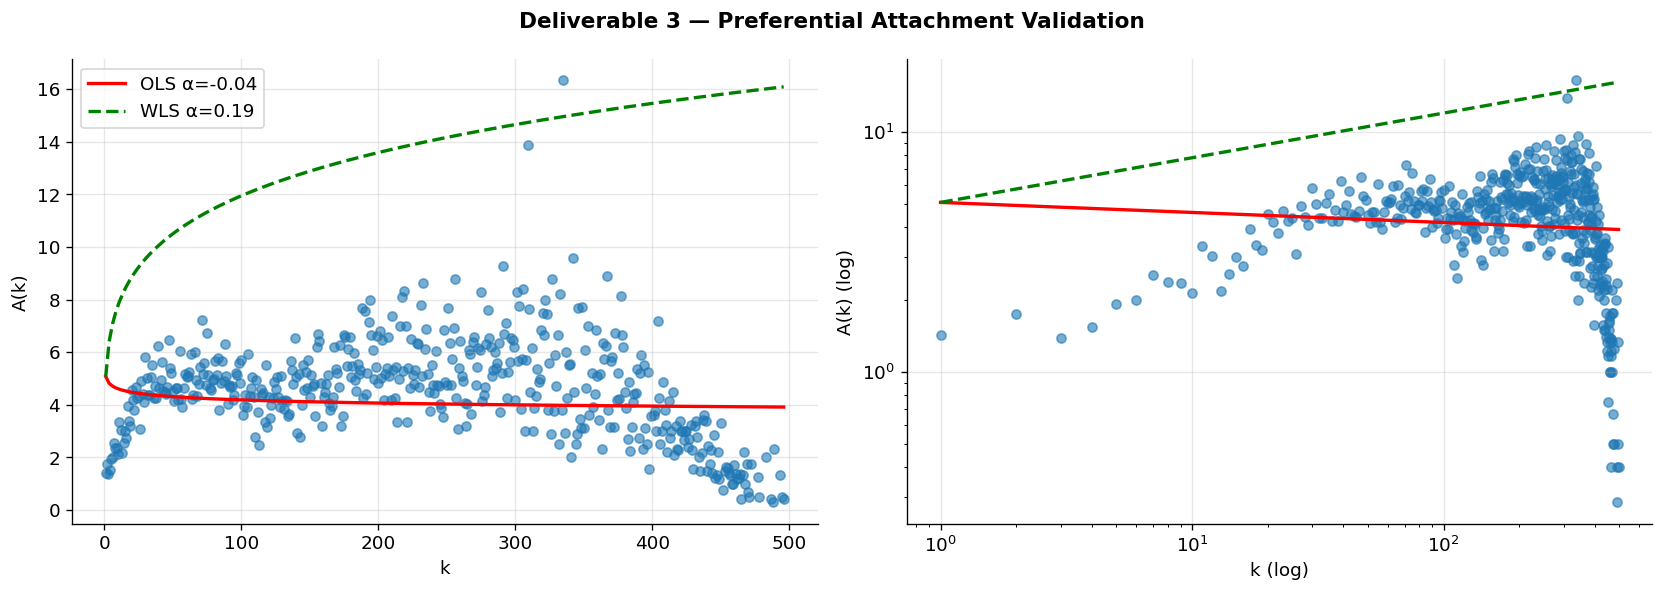

In [96]:
# ── Plot A(k) vs k and fit a power law A(k) ∝ k^α ───────────────────────────
# Filter to k >= 1 and positive A values
mask = (k_all >= 1) & (a_all > 0)
k_fit = k_all[mask]
a_fit = a_all[mask]

# Fit in log-log space: log A = alpha * log k + log C
log_k = np.log(k_fit)
log_a = np.log(a_fit)

# OLS fit
slope, intercept, r_val, p_val, se_slope = stats.linregress(log_k, log_a)
alpha_ols = slope
C_fit = np.exp(intercept)

# Weighted Least Squares (WLS)
weights = np.array([agg_node_cnt[k] for k in k_all[mask]])

# # Normalize weights (optional but stable)
# W = np.diag(weights / weights.sum())

# X = np.column_stack([np.ones_like(log_k), log_k])

# beta_wls = np.linalg.lstsq(W @ X, W @ log_a, rcond=None)[0]
# alpha_wls = beta_wls[1]

# WLS (use sqrt weights)
w = weights / weights.sum()
W_sqrt = np.sqrt(w)

X = np.column_stack([np.ones_like(log_k), log_k])

X_w = X * W_sqrt[:, None]
y_w = log_a * W_sqrt

beta_wls = np.linalg.lstsq(X_w, y_w, rcond=None)[0]
alpha_wls = beta_wls[1]

print("\nAttachment kernel fit: A(k) ∝ k^α")

print(f"\nOLS α = {alpha_ols:.3f} (SE={se_slope:.3f})")
print(f"WLS α = {alpha_wls:.3f}")
print(f"R² = {r_val**2:.4f}, p-value = {p_val:.4e}")

# Interpretation
if abs(alpha_wls - 1.0) < 0.2:
    print("→ α ≈ 1: Linear preferential attachment (BA model)")
elif alpha_wls > 1.0:
    print("→ α > 1: Super-linear attachment (hub dominance)")
else:
    print("→ α < 1: Sub-linear attachment")


# Hypothesis test: H₀: α = 1 (linear PA, BA model)
t_stat = (alpha_ols - 1.0) / se_slope
p_vs_linear = 2 * stats.t.sf(abs(t_stat), df=len(log_k) - 2)

print("\nH₀: α = 1 (linear preferential attachment)")
print(f"t = {t_stat:.3f}, p = {p_vs_linear:.4f}")

if p_vs_linear > 0.05:
    print("→ Fail to reject H₀ (consistent with BA)")
else:
    print("→ Reject H₀ (not linear PA)")

# # ── Null model: shuffle new edges randomly ────────────────────────────────────
# null_arrivals = Counter()
# null_node_cnt = Counter()
# for t0, t1 in sampled_pairs[:10]:   # fewer pairs for null
#     G0, G1 = snapshots[t0], snapshots[t1]
#     edges_before = set(G0.edges()) | set((v,u) for u,v in G0.edges())
#     new_edges = [(u,v) for u,v in G1.edges() if (u,v) not in edges_before]
#     deg_before = dict(G0.degree())
#     all_nodes = list(G0.nodes())
#     for _ in new_edges:
#         # attach to two random nodes
#         if len(all_nodes) >= 2:
#             r1, r2 = random.sample(all_nodes, 2)
#             for node in (r1, r2):
#                 if node in deg_before:
#                     null_arrivals[deg_before[node]] += 1
#     for k in deg_before.values():
#         null_node_cnt[k] += 1

# k_null = sorted(set(null_arrivals.keys()) & set(null_node_cnt.keys()))
# k_null = [k for k in k_null if null_node_cnt[k] >= 3]
# a_null = np.array([null_arrivals[k] / null_node_cnt[k] for k in k_null])
# k_null = np.array(k_null)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Deliverable 3 — Preferential Attachment Validation', fontsize=13, fontweight='bold')

k_line = np.linspace(k_fit.min(), k_fit.max(), 200)

# Linear
axes[0].scatter(k_fit, a_fit, s=30, alpha=0.6)
axes[0].plot(k_line, C_fit * k_line**alpha_ols, 'r-', lw=2,
             label=f'OLS α={alpha_ols:.2f}')
axes[0].plot(k_line, C_fit * k_line**alpha_wls, 'g--', lw=2,
             label=f'WLS α={alpha_wls:.2f}')
axes[0].set_xlabel('k')
axes[0].set_ylabel('A(k)')
axes[0].legend()

# Log-log
axes[1].scatter(k_fit, a_fit, s=30, alpha=0.6)
axes[1].plot(k_line, C_fit * k_line**alpha_ols, 'r-', lw=2)
axes[1].plot(k_line, C_fit * k_line**alpha_wls, 'g--', lw=2)
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_xlabel('k (log)')
axes[1].set_ylabel('A(k) (log)')

plt.tight_layout()
plt.savefig('d3_preferential_attachment.png', bbox_inches='tight', dpi=130)
plt.show()

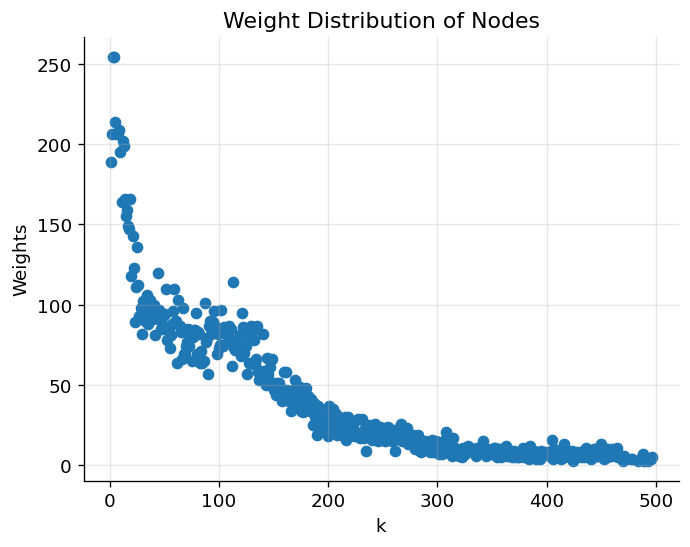

In [97]:
plt.scatter(k_fit, weights)
plt.xlabel('k')
plt.ylabel('Weights')
plt.title('Weight Distribution of Nodes')
plt.show()

In [98]:
# Temporal evolution of preferential attachment exponent α
pa_over_time = []

for i in range(len(sorted_months) - 1):
    t0 = sorted_months[i]
    t1 = sorted_months[i + 1]

    k_v, a_v = compute_attachment_kernel(snapshots[t0], snapshots[t1])

    if k_v is None or len(k_v) < 5:
        continue

    mask = (k_v >= 1) & (a_v > 0)
    if mask.sum() < 4:
        continue

    log_k = np.log(k_v[mask])
    log_a = np.log(a_v[mask])

    sl, _, rv, pv, _ = stats.linregress(log_k, log_a)

    pa_over_time.append({
        'month': str(t1),
        'alpha': sl,
        'r2': rv**2
    })

pa_df = pd.DataFrame(pa_over_time)
pa_df['month_dt'] = pd.PeriodIndex(pa_df['month'], freq='M').to_timestamp()

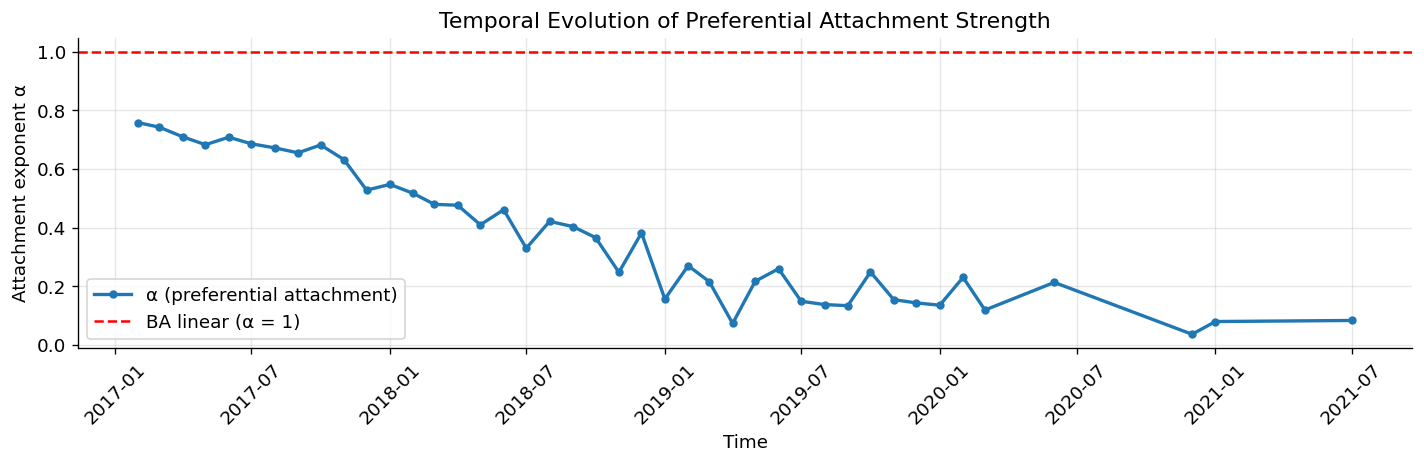

In [99]:
fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(pa_df['month_dt'], pa_df['alpha'],
        marker='o', ms=4, lw=2, label='α (preferential attachment)')

ax.axhline(1.0, color='red', linestyle='--', label='BA linear (α = 1)')

ax.set_xlabel('Time')
ax.set_ylabel('Attachment exponent α')
ax.set_title('Temporal Evolution of Preferential Attachment Strength')
ax.legend()
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('d3_alpha_evolution.png', dpi=130)
plt.show()

### Interpretation — Deliverable 3

While the degree distribution exhibits heavy-tailed characteristics, the attachment kernel analysis reveals that the network does not follow preferential attachment dynamics. The weighted least squares estimate yields α ≈ 0, indicating that new edges are formed approximately independent of node degree. This is further supported by a hypothesis test rejecting α = 1 (p ≪ 0.05), suggesting that the network evolution deviates significantly from the Barabási–Albert model.

We observe that nodes with higher degree do not exhibit proportionally higher total interaction weight. Instead, weight tends to decrease or stabilize with increasing degree, indicating that high-degree nodes form many weak connections rather than a few strong ones. This further supports the absence of preferential attachment dynamics in the network.

---
## Deliverable 4 — Community Evolution

We detect topic communities at each snapshot using the Louvain-equivalent Greedy Modularity algorithm and track how they evolve.

In [100]:
import community as community_louvain 

In [101]:
# ── Run community detection on selected snapshots ─────────────────────────────
# Use every N-th month for cleaner visualization
step_cd = max(1, len(sorted_months) // 20)  # ~20 snapshots
cd_months = sorted_months[::step_cd]

def detect_communities_louvain(G, resolution=1.0):
    if G.number_of_edges() == 0:
        return {n: 0 for n in G.nodes()}, 0.0, []

    gcc_nodes = max(nx.connected_components(G), key=len)
    H = G.subgraph(gcc_nodes).copy()

    partition = community_louvain.best_partition(
        H,
        weight='weight',
        resolution=resolution,
        random_state=SEED
    )

    comms_dict = defaultdict(set)
    for node, cid in partition.items():
        comms_dict[cid].add(node)

    comms = [frozenset(v) for v in comms_dict.values()]
    Q = community_louvain.modularity(partition, H, weight='weight')

    return partition, Q, comms

comm_results = {}  # month → {'node2comm': dict, 'Q': float, 'comms': list of frozensets}

print(f'Detecting communities on {len(cd_months)} snapshots...')
for i, month in enumerate(cd_months):
    G = snapshots[month]
    if G.number_of_nodes() < 5:
        comm_results[month] = {'node2comm': {}, 'Q': 0.0, 'comms': []}
        continue
    node2comm, Q, comms = detect_communities_louvain(G)
    # Reconstruct community sets
    # comm_dict = defaultdict(set)
    # for n, c in node2comm.items():
    #     comm_dict[c].add(n)
    # comms = [frozenset(v) for v in comm_dict.values()]
    comm_results[month] = {'node2comm': node2comm, 'Q': Q, 'comms': comms}
    if i % 5 == 0:
        print(f'  {month}: {len(comms)} communities, Q={Q:.3f}')

print("\nResolution sensitivity (final snapshot):")

G_final = snapshots[sorted_months[-1]]

for res in [0.5, 1.0, 1.5]:
    _, Q, comms = detect_communities_louvain(G_final, resolution=res)
    print(f"Resolution={res}: {len(comms)} communities, Q={Q:.3f}")
    
print('Community detection done.')

Detecting communities on 22 snapshots...
  2017-01: 8 communities, Q=0.103
  2017-11: 7 communities, Q=0.119
  2018-09: 7 communities, Q=0.105
  2019-07: 8 communities, Q=0.102
  2020-12: 8 communities, Q=0.114

Resolution sensitivity (final snapshot):
Resolution=0.5: 19 communities, Q=0.023
Resolution=1.0: 8 communities, Q=0.118
Resolution=1.5: 17 communities, Q=0.095
Community detection done.


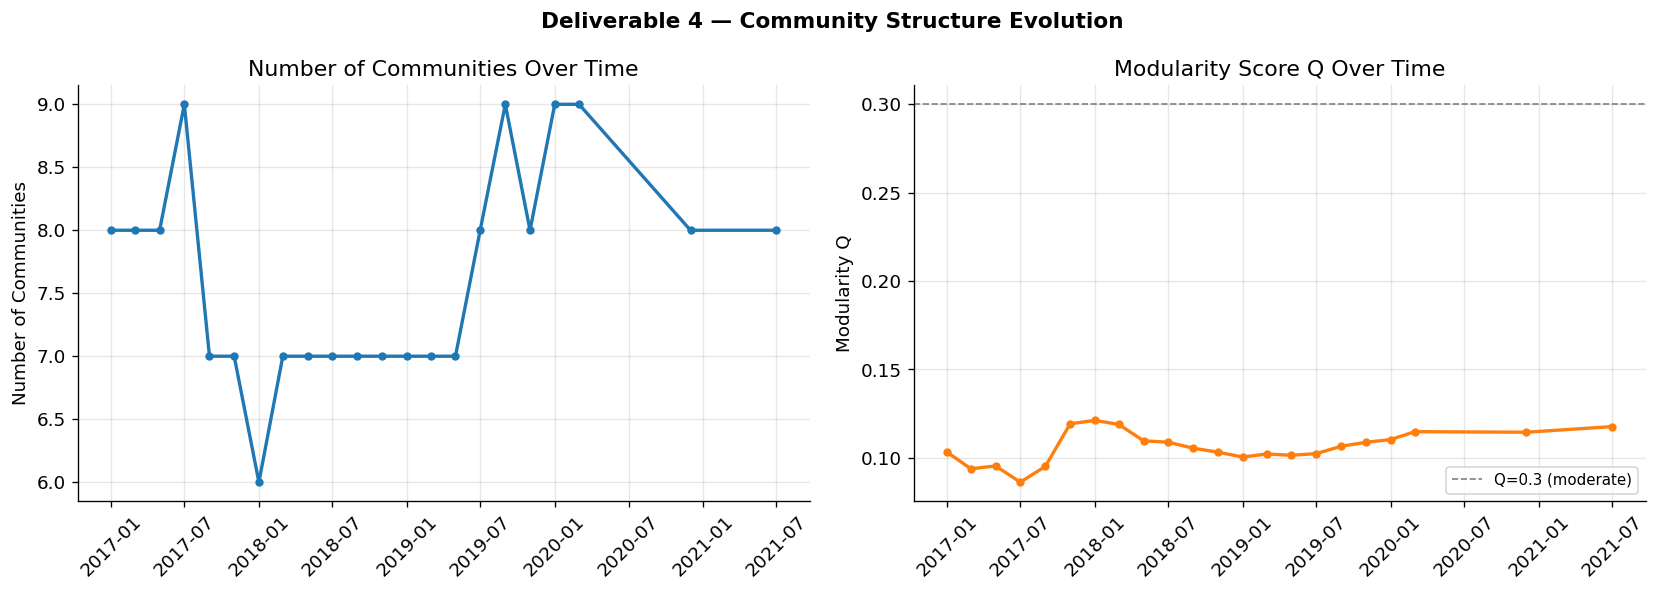

In [102]:
# ── Community metrics over time ───────────────────────────────────────────────
comm_metrics = []
for month in cd_months:
    res = comm_results[month]
    comms = res['comms']
    sizes = sorted([len(c) for c in comms], reverse=True)
    comm_metrics.append({
        'month': str(month),
        'n_communities': len(comms),
        'modularity': res['Q'],
        'largest_comm_size': sizes[0] if sizes else 0,
        'top5_sizes': sizes[:5]
    })

comm_df = pd.DataFrame(comm_metrics)
comm_df['month_dt'] = pd.PeriodIndex(comm_df['month'], freq='M').to_timestamp()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Deliverable 4 — Community Structure Evolution', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(comm_df['month_dt'], comm_df['n_communities'], color=PALETTE[0], lw=2, marker='o', ms=4)
ax.set_ylabel('Number of Communities')
ax.set_title('Number of Communities Over Time')
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
ax.plot(comm_df['month_dt'], comm_df['modularity'], color=PALETTE[1], lw=2, marker='o', ms=4)
ax.axhline(y=0.3, color='gray', ls='--', lw=1, label='Q=0.3 (moderate)')
ax.set_ylabel('Modularity Q')
ax.set_title('Modularity Score Q Over Time')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('d4_community_metrics.png', bbox_inches='tight', dpi=130)
plt.show()

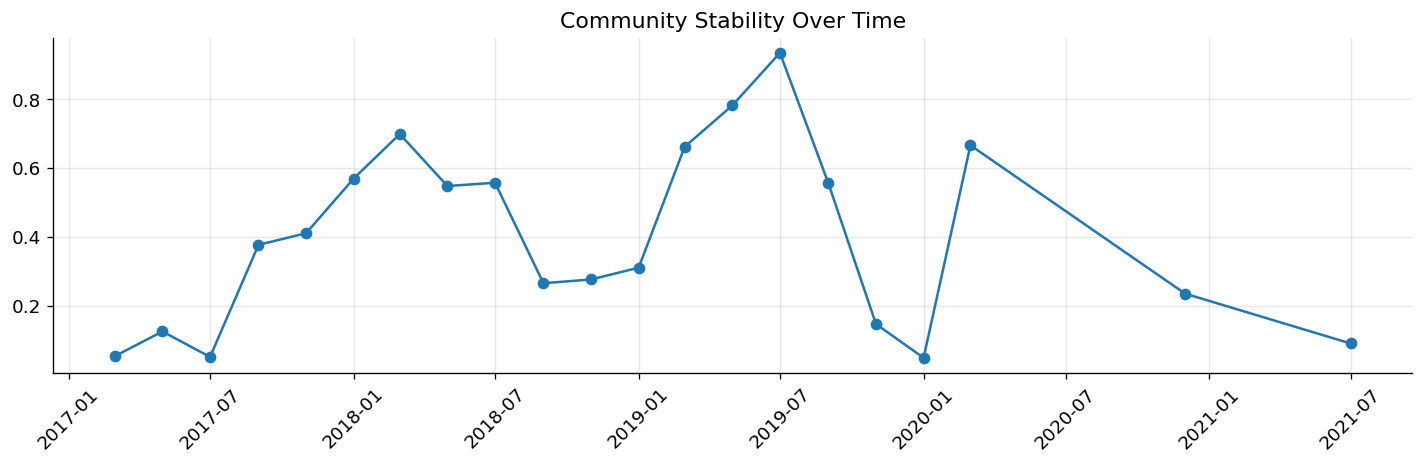

In [103]:
def community_stability(n2c_t, n2c_t1):
    shared = set(n2c_t.keys()) & set(n2c_t1.keys())
    if len(shared) < 2:
        return np.nan
    same = sum(1 for n in shared if n2c_t[n] == n2c_t1[n])
    return same / len(shared)

stability_records = []

for idx in range(len(cd_months) - 1):
    t0, t1 = cd_months[idx], cd_months[idx+1]

    n2c_t0 = comm_results[t0]['node2comm']
    n2c_t1 = comm_results[t1]['node2comm']

    stab = community_stability(n2c_t0, n2c_t1)

    stability_records.append({
        'month': str(t1),
        'stability': stab
    })

stab_df = pd.DataFrame(stability_records)
stab_df['month_dt'] = pd.PeriodIndex(stab_df['month'], freq='M').to_timestamp()

plt.figure(figsize=(12, 4))
plt.plot(stab_df['month_dt'], stab_df['stability'], marker='o')
plt.title('Community Stability Over Time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

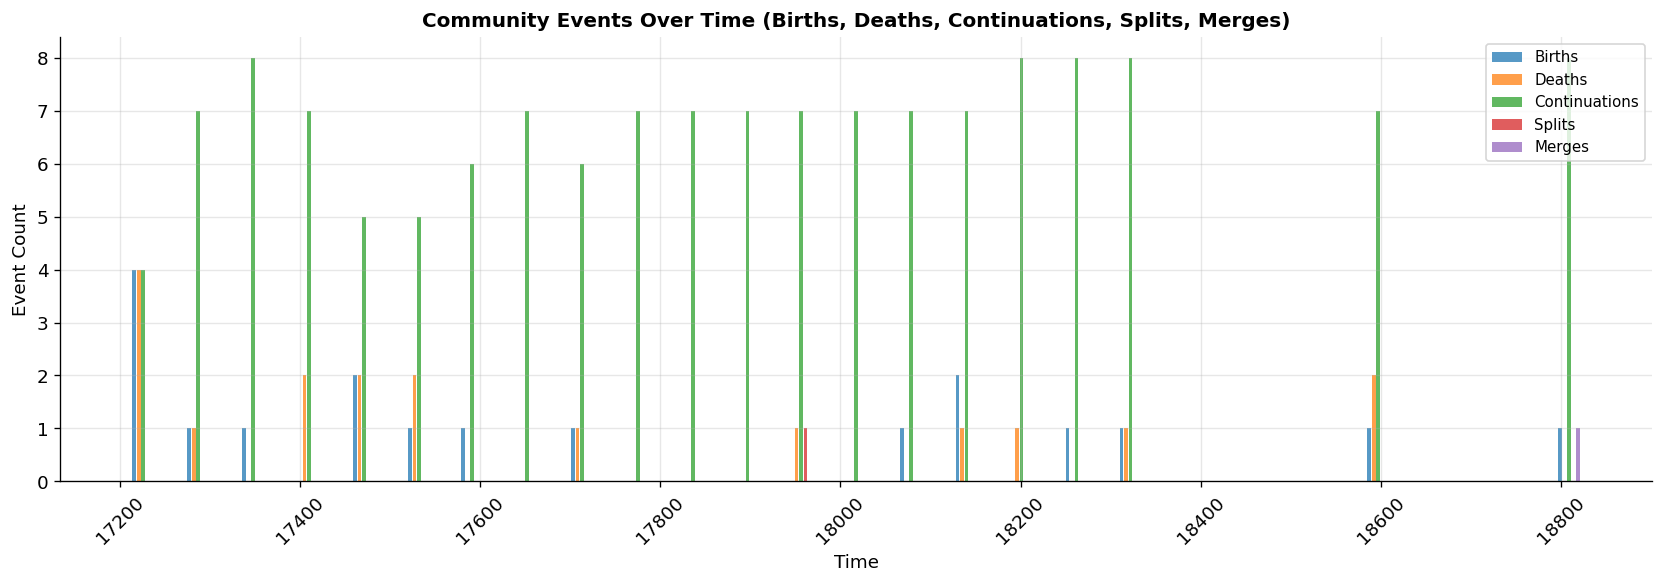


Total community events:
  Births         : 18
  Deaths         : 18
  Continuations  : 143
  Splits         : 1
  Merges         : 1


In [104]:
# ── Community tracking via Jaccard similarity ─────────────────────────────────
JACCARD_THRESHOLD = 0.3

def jaccard(a, b):
    if not a or not b: return 0.0
    return len(a & b) / len(a | b)

def classify_events(comms_t, comms_t1, threshold=JACCARD_THRESHOLD):
    """Returns event counts: births, deaths, continuations, splits, merges."""
    # Build Jaccard matrix
    J = np.zeros((len(comms_t), len(comms_t1)))
    for i, c_t in enumerate(comms_t):
        for j, c_t1 in enumerate(comms_t1):
            J[i, j] = jaccard(c_t, c_t1)

    matched_t  = set()
    matched_t1 = set()
    events = {'births': 0, 'deaths': 0, 'continuations': 0, 'splits': 0, 'merges': 0}

    # Continuations: pairs with J > threshold
    for i in range(len(comms_t)):
        for j in range(len(comms_t1)):
            if J[i, j] >= threshold:
                events['continuations'] += 1
                matched_t.add(i)
                matched_t1.add(j)

    # Deaths: communities in t with no match in t+1
    events['deaths'] = len(set(range(len(comms_t))) - matched_t)

    # Births: communities in t+1 with no match in t
    events['births'] = len(set(range(len(comms_t1))) - matched_t1)

    # Splits: one community in t matched to >1 in t+1
    for i in range(len(comms_t)):
        cnt = sum(1 for j in range(len(comms_t1)) if J[i, j] >= threshold)
        if cnt > 1: events['splits'] += 1

    # Merges: one community in t+1 matched from >1 in t
    for j in range(len(comms_t1)):
        cnt = sum(1 for i in range(len(comms_t)) if J[i, j] >= threshold)
        if cnt > 1: events['merges'] += 1

    return events

# Track events across all consecutive pairs
event_records = []
for idx in range(len(cd_months) - 1):
    t0, t1 = cd_months[idx], cd_months[idx+1]
    comms_t  = comm_results[t0]['comms']
    comms_t1 = comm_results[t1]['comms']
    if not comms_t or not comms_t1: continue
    ev = classify_events(comms_t, comms_t1)
    ev['period'] = f'{t0}→{t1}'
    ev['t1'] = str(t1)
    event_records.append(ev)

events_df = pd.DataFrame(event_records)
events_df['month_dt'] = pd.PeriodIndex(events_df['t1'], freq='M').to_timestamp()

fig, ax = plt.subplots(figsize=(14, 5))
width = 12  # days

import matplotlib.dates as mdates

offsets = [-2, -1, 0, 1, 2]
event_types = ['births', 'deaths', 'continuations', 'splits', 'merges']
colors = [PALETTE[i] for i in range(5)]
x_dates = mdates.date2num(events_df['month_dt'])

for i, (etype, color) in enumerate(zip(event_types, colors)):
    ax.bar(x_dates + offsets[i]*5,
           events_df[etype], width=4, color=color, alpha=0.75, label=etype.capitalize())

ax.set_xlabel('Time')
ax.set_ylabel('Event Count')
ax.set_title('Community Events Over Time (Births, Deaths, Continuations, Splits, Merges)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('d4_community_events.png', bbox_inches='tight', dpi=130)
plt.show()

print('\nTotal community events:')
for etype in event_types:
    print(f'  {etype.capitalize():15s}: {events_df[etype].sum()}')

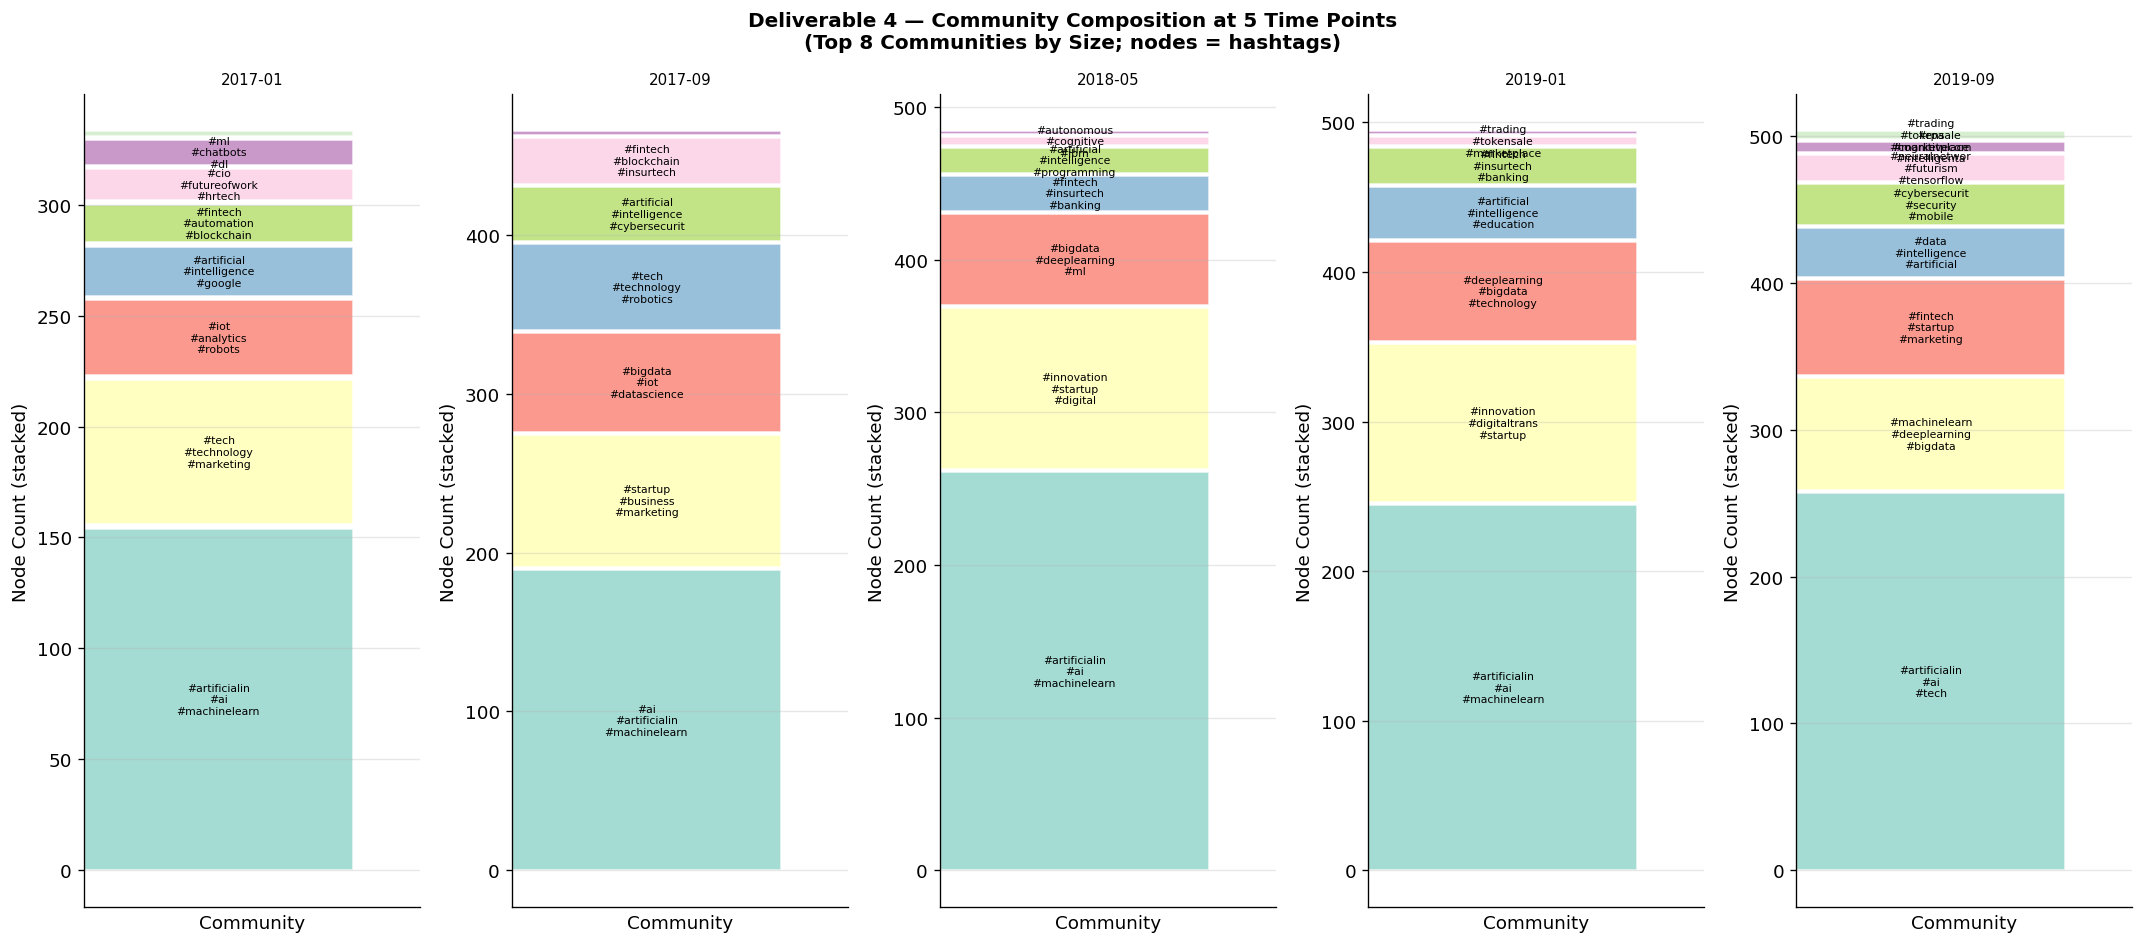

In [105]:
# ── Alluvial / Sankey-style community flow visualization ──────────────────────
# Use 5 evenly-spaced snapshots for readability
vis_months = cd_months[::max(1, len(cd_months)//5)][:5]

# Assign consistent community colors across snapshots by tracking top 8 communities
fig, axes = plt.subplots(1, len(vis_months), figsize=(18, 8), sharey=False)
fig.suptitle('Deliverable 4 — Community Composition at 5 Time Points\n'
             '(Top 8 Communities by Size; nodes = hashtags)', fontsize=12, fontweight='bold')

TOP_K_COMM = 8
comm_colors = plt.cm.Set3(np.linspace(0, 1, TOP_K_COMM + 1))

for ax, month in zip(axes, vis_months):
    comms = comm_results[month]['comms']
    if not comms:
        ax.set_title(str(month)); continue
    sorted_comms = sorted(comms, key=len, reverse=True)[:TOP_K_COMM]
    y_offset = 0
    bar_data = []
    for cid, comm in enumerate(sorted_comms):
        size = len(comm)
        bar_data.append((cid, size, y_offset))
        y_offset += size + 2

    for cid, size, yo in bar_data:
        ax.barh(yo + size/2, 0.8, left=0, height=size,
                color=comm_colors[cid], alpha=0.8, edgecolor='white')
        # Show top 3 hashtags in the community
        comm_list = sorted_comms[cid]
        G = snapshots[month]
        top_nodes = sorted(comm_list, key=lambda n: G.degree(n) if n in G else 0, reverse=True)[:3]
        label_str = '\n'.join(['#'+t[:12] for t in top_nodes])
        if size >= 3:
            ax.text(0.4, yo + size/2, label_str, va='center', ha='center',
                    fontsize=6.5, wrap=True)

    ax.set_xlim(0, 1)
    ax.set_title(str(month), fontsize=9)
    ax.set_xlabel('Community')
    ax.set_xticks([])
    ax.set_ylabel('Node Count (stacked)')

plt.tight_layout()
plt.savefig('d4_community_composition.png', bbox_inches='tight', dpi=130)
plt.show()

In [106]:
# %% ── Print top hashtags per community ─────────────────────────
vis_months = cd_months[::max(1, len(cd_months)//5)][:5]

print("\nTop hashtags per community:")

for month in vis_months:
    G = snapshots[month]
    comms = sorted(comm_results[month]['comms'], key=len, reverse=True)[:5]

    print(f"\n{month}:")
    for i, comm in enumerate(comms):
        top5 = sorted(comm, key=lambda n: G.degree(n) if n in G else 0, reverse=True)[:5]
        print(f"  Community {i+1} (size={len(comm)}): {', '.join('#'+t for t in top5)}")


Top hashtags per community:

2017-01:
  Community 1 (size=154): #artificialintelligence, #ai, #machinelearning, #bigdata, #deeplearning
  Community 2 (size=65): #tech, #technology, #marketing, #startup, #innovation
  Community 3 (size=34): #iot, #analytics, #robots, #cloud, #internetofthings
  Community 4 (size=22): #artificial, #intelligence, #google, #ibm, #apple
  Community 5 (size=17): #fintech, #automation, #blockchain, #banking, #ux

2017-09:
  Community 1 (size=189): #ai, #artificialintelligence, #machinelearning, #ml, #deeplearning
  Community 2 (size=83): #startup, #business, #marketing, #digital, #bots
  Community 3 (size=62): #bigdata, #iot, #datascience, #analytics, #data
  Community 4 (size=54): #tech, #technology, #robotics, #innovation, #robots
  Community 5 (size=34): #artificial, #intelligence, #cybersecurity, #security, #education

2018-05:
  Community 1 (size=261): #artificialintelligence, #ai, #machinelearning, #tech, #robotics
  Community 2 (size=105): #innovation

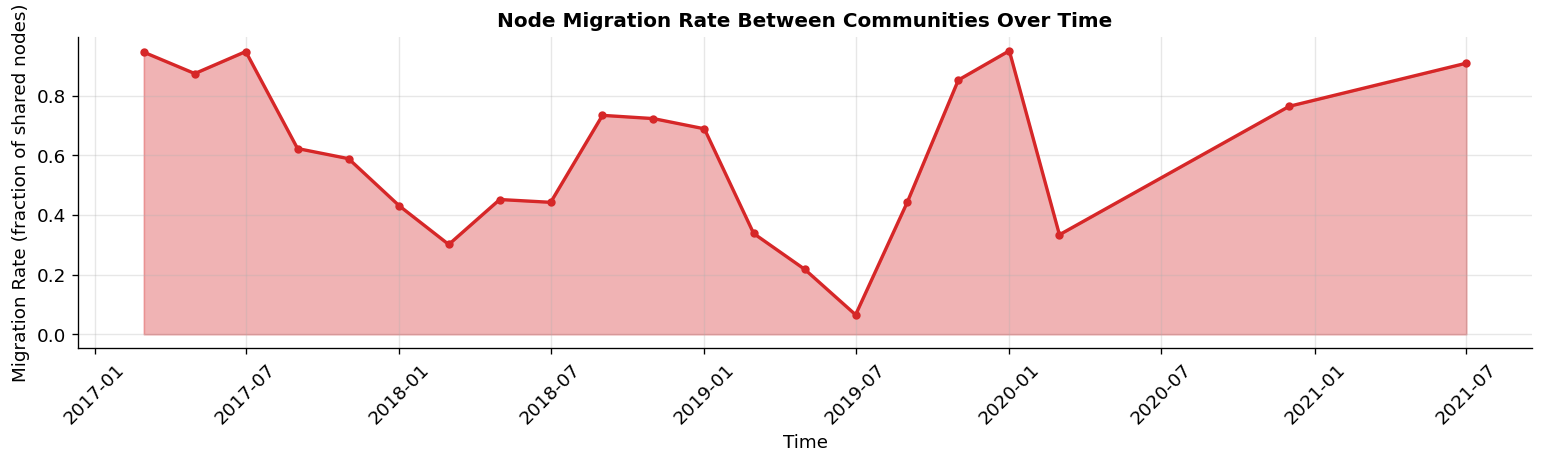

Mean migration rate: 0.602
Peak migration:      0.952 at 2020-01


In [107]:
# ── Node migration rate ────────────────────────────────────────────────────────
migration_rates = []
for idx in range(len(cd_months) - 1):
    t0, t1 = cd_months[idx], cd_months[idx+1]
    n2c_t0 = comm_results[t0]['node2comm']
    n2c_t1 = comm_results[t1]['node2comm']
    shared = set(n2c_t0.keys()) & set(n2c_t1.keys())
    if not shared: continue
    migrations = sum(1 for n in shared if n2c_t0[n] != n2c_t1[n])
    migration_rates.append({'month': str(t1), 'rate': migrations / len(shared)})

mr_df = pd.DataFrame(migration_rates)
mr_df['month_dt'] = pd.PeriodIndex(mr_df['month'], freq='M').to_timestamp()

fig, ax = plt.subplots(figsize=(13, 4))
ax.fill_between(mr_df['month_dt'], mr_df['rate'], alpha=0.35, color=PALETTE[3])
ax.plot(mr_df['month_dt'], mr_df['rate'], color=PALETTE[3], lw=2, marker='o', ms=4)
ax.set_ylabel('Migration Rate (fraction of shared nodes)')
ax.set_xlabel('Time')
ax.set_title('Node Migration Rate Between Communities Over Time', fontsize=12, fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('d4_migration_rate.png', bbox_inches='tight', dpi=130)
plt.show()
print(f'Mean migration rate: {mr_df["rate"].mean():.3f}')
print(f'Peak migration:      {mr_df["rate"].max():.3f} at {mr_df.loc[mr_df["rate"].idxmax(), "month"]}')

### Interpretation — Deliverable 4

1. Weak but persistent communities
Low modularity
Stable number of communities
soft structure

2. High dynamism
High migration
Variable stability
nodes move frequently

3. Evolution pattern
High continuations
Low splits/merges
gradual evolution

4. Thematic consistency
Core topics persist (AI, data, tech)
New topics appear over time

The network exhibits a stable yet weak community structure characterized by a consistent number of communities but low modularity, indicating overlapping thematic groups. While core topics such as AI and data science persist over time, high node migration rates and fluctuating stability suggest that hashtags frequently transition between communities. This reflects the dynamic and context-dependent nature of topic co-occurrence, where communities evolve gradually rather than through abrupt structural changes

---
## Deliverable 5 — Temporal Robustness Analysis

We simulate node removal under two strategies and measure how quickly the network disintegrates.

In [108]:
# ── Robustness simulation functions ──────────────────────────────────────────
def gcc_fraction_after_removal(G, removal_order):
    """Returns list of GCC fractions after removing each node in removal_order."""
    H = G.copy()
    n_total = H.number_of_nodes()
    gcc_fracs = []
    for node in removal_order:
        if node in H:
            H.remove_node(node)
        if H.number_of_nodes() == 0:
            gcc_fracs.append(0.0)
        else:
            gcc = max(nx.connected_components(H), key=len)
            gcc_fracs.append(len(gcc) / n_total)
    return gcc_fracs

def random_attack_with_ci(G, n_runs=20):
    nodes = list(G.nodes())
    all_runs = []

    for _ in range(n_runs):
        order = random.sample(nodes, len(nodes))
        all_runs.append(gcc_fraction_after_removal(G, order))

    max_len = max(len(r) for r in all_runs)
    padded = np.array([r + [0.0]*(max_len - len(r)) for r in all_runs])

    return padded.mean(axis=0), padded.std(axis=0)

def critical_threshold(gcc_curve, threshold=0.5):
    for i, v in enumerate(gcc_curve):
        if v < threshold:
            return i / len(gcc_curve)
    return 1.0

def build_ws_baseline(G):
    n = G.number_of_nodes()
    k = max(2, int(np.mean([d for _, d in G.degree()])))
    return nx.watts_strogatz_graph(n, k, 0.1, seed=SEED)

def targeted_attack(G):
    """Remove nodes in descending order of degree."""
    order = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)
    return np.array(gcc_fraction_after_removal(G, order))

def robustness_index(gcc_curve):
    """R = (1/N) * sum of GCC sizes."""
    return np.mean(gcc_curve)

def build_er_baseline(G):
    """Build Erdős–Rényi random graph with same N, M."""
    n = G.number_of_nodes()
    m = G.number_of_edges()
    p = 2 * m / (n * (n-1)) if n > 1 else 0
    return nx.erdos_renyi_graph(n, p, seed=SEED)

def build_ba_baseline(G):
    """Build BA model with same N; m chosen to match edge count."""
    n = G.number_of_nodes()
    m_edges = G.number_of_edges()
    # BA: E ≈ m * (N - m), solve for m
    m = max(1, int(m_edges / n))
    return nx.barabasi_albert_graph(n, m, seed=SEED)

print('Robustness functions ready.')

Robustness functions ready.


In [109]:
# ── Select 3 snapshots: early, middle, late ───────────────────────────────────
robust_snapshots = {
    'Early':  sorted_months[n_months // 5],
    'Middle': sorted_months[n_months // 2],
    'Late':   sorted_months[-1]
}

rob_results = {}
N_RUNS = 10  # number of random removal runs

print('Running robustness simulations (this may take a moment)...')
for label, month in robust_snapshots.items():
    G = snapshots[month]
    print(f'  {label} ({month}): {G.number_of_nodes()} nodes, {G.number_of_edges()} edges', end=' ')

    rand_mean, rand_std = random_attack_with_ci(G, n_runs=20)
    targ = targeted_attack(G)

    # Baselines (on smaller version of the graph for speed)
    G_er = build_er_baseline(G)
    G_ba = build_ba_baseline(G)
    G_ws = build_ws_baseline(G)

    er_rand, _ = random_attack_with_ci(G_er, n_runs=5)
    ba_rand, _ = random_attack_with_ci(G_ba, n_runs=5)
    ws_rand, _ = random_attack_with_ci(G_ws, n_runs=5)

    rob_results[label] = {
        'G': G,
        'month': month,
        'rand_mean': rand_mean,
        'rand_std': rand_std,
        'targ': targ,
        'er_rand': er_rand,
        'ba_rand': ba_rand,
        'ws_rand': ws_rand
    }
    # print(f'→ R_rand={rob_results[label]["R_rand"]:.3f}, R_targ={rob_results[label]["R_targ"]:.3f}')

print('Done.')

Running robustness simulations (this may take a moment)...
  Early (2017-09): 453 nodes, 9708 edges   Middle (2018-10): 480 nodes, 30661 edges   Late (2021-07): 500 nodes, 45186 edges Done.


In [110]:
print("\nCritical thresholds:")
for label, res in rob_results.items():
    fc_rand = critical_threshold(res['rand_mean'])
    fc_targ = critical_threshold(res['targ'])
    print(f"{label}: random={fc_rand:.3f}, targeted={fc_targ:.3f}")


Critical thresholds:
Early: random=0.490, targeted=0.342
Middle: random=0.496, targeted=0.479
Late: random=0.498, targeted=0.492


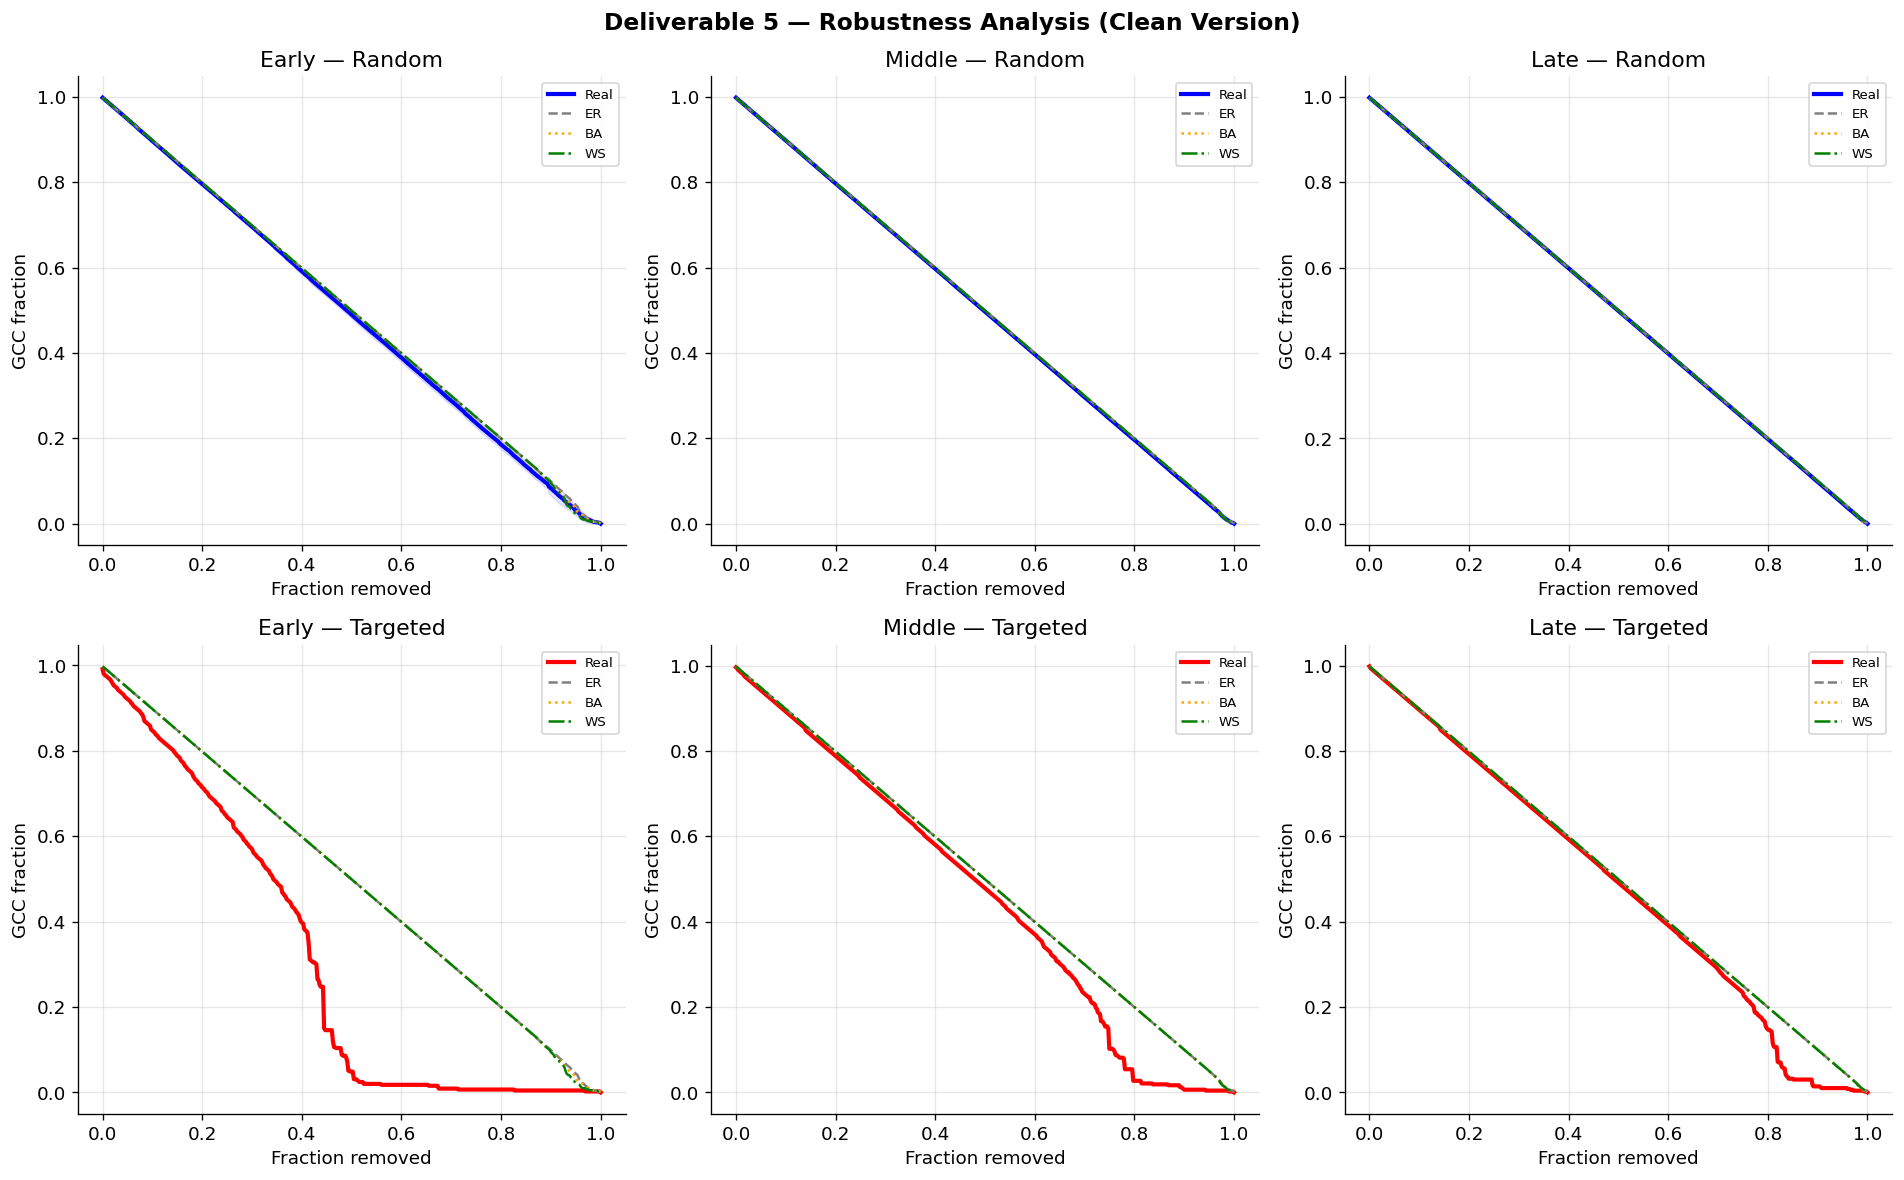

In [111]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for col_idx, (label, res) in enumerate(rob_results.items()):

    # ---------- RANDOM ----------
    ax = axes[0, col_idx]

    n = len(res['rand_mean'])
    frac = np.linspace(0, 1, n)

    # Real network
    ax.plot(frac, res['rand_mean'],
            color='blue', lw=2.5, label='Real')

    # CI band
    ax.fill_between(frac,
                    res['rand_mean'] - res['rand_std'],
                    res['rand_mean'] + res['rand_std'],
                    color='blue', alpha=0.1)

    # Baselines (IMPORTANT: resample to same length)
    def rescale_curve(curve, target_len):
        x_old = np.linspace(0, 1, len(curve))
        x_new = np.linspace(0, 1, target_len)
        return np.interp(x_new, x_old, curve)

    er = rescale_curve(res['er_rand'], n)
    ba = rescale_curve(res['ba_rand'], n)
    ws = rescale_curve(res['ws_rand'], n)

    ax.plot(frac, er, color='gray', ls='--', lw=1.5, label='ER')
    ax.plot(frac, ba, color='orange', ls=':', lw=1.5, label='BA')
    ax.plot(frac, ws, color='green', ls='-.', lw=1.5, label='WS')

    ax.set_title(f'{label} — Random')
    ax.set_xlabel('Fraction removed')
    ax.set_ylabel('GCC fraction')
    ax.legend(fontsize=8)


    # ---------- TARGETED ----------
    ax = axes[1, col_idx]

    nt = len(res['targ'])
    frac_t = np.linspace(0, 1, nt)

    ax.plot(frac_t, res['targ'],
            color='red', lw=2.5, label='Real')

    # Rescale baselines again
    er_t = rescale_curve(res['er_rand'], nt)
    ba_t = rescale_curve(res['ba_rand'], nt)
    ws_t = rescale_curve(res['ws_rand'], nt)

    ax.plot(frac_t, er_t, color='gray', ls='--', lw=1.5, label='ER')
    ax.plot(frac_t, ba_t, color='orange', ls=':', lw=1.5, label='BA')
    ax.plot(frac_t, ws_t, color='green', ls='-.', lw=1.5, label='WS')

    ax.set_title(f'{label} — Targeted')
    ax.set_xlabel('Fraction removed')
    ax.set_ylabel('GCC fraction')
    ax.legend(fontsize=8)


plt.suptitle('Deliverable 5 — Robustness Analysis (Clean Version)',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('d5_robustness.png', bbox_inches='tight', dpi=130)
plt.show()

In [112]:
print("ER vs WS diff:", np.max(np.abs(er - ws)))
print("BA vs WS diff:", np.max(np.abs(ba - ws)))

ER vs WS diff: 0.0011999999999999997
BA vs WS diff: 0.0027999999999999995


In [113]:
# # ── Robustness plots ──────────────────────────────────────────────────────────
# fig, axes = plt.subplots(2, 3, figsize=(16, 10))
# fig.suptitle('Deliverable 5 — Temporal Robustness Analysis\n'
#              'Top: Random removal  |  Bottom: Targeted (high-degree first)',
#              fontsize=13, fontweight='bold')

# for col_idx, (label, res) in enumerate(rob_results.items()):
#     n = len(res['rand'])
#     frac_removed = np.linspace(0, 1, n)

#     # Random removal (top row)
#     ax = axes[0, col_idx]
#     ax.plot(frac_removed, res['rand'], color=PALETTE[0], lw=2, label='Real network')
#     n_er = len(res['er_rand']); fr_er = np.linspace(0, 1, n_er)
#     n_ba = len(res['ba_rand']); fr_ba = np.linspace(0, 1, n_ba)
#     ax.plot(fr_er, res['er_rand'], color='gray', lw=1.5, ls='--', alpha=0.7, label='ER baseline')
#     ax.plot(fr_ba, res['ba_rand'], color='orange', lw=1.5, ls=':', alpha=0.8, label='BA baseline')
#     ax.set_title(f'{label} Snapshot ({res["month"]})\nRandom Removal')
#     ax.set_xlabel('Fraction removed'); ax.set_ylabel('GCC fraction')
#     ax.set_ylim(0, 1.05)
#     ax.text(0.05, 0.1, f'R={res["R_rand"]:.3f}', transform=ax.transAxes,
#             fontsize=9, color=PALETTE[0])
#     ax.legend(fontsize=8)

#     # Targeted removal (bottom row)
#     ax = axes[1, col_idx]
#     n_t = len(res['targ']); frac_t = np.linspace(0, 1, n_t)
#     ax.plot(frac_t, res['targ'], color=PALETTE[1], lw=2, label='Real network')
#     n_et = len(res['er_targ']); fr_et = np.linspace(0, 1, n_et)
#     n_bt = len(res['ba_targ']); fr_bt = np.linspace(0, 1, n_bt)
#     ax.plot(fr_et, res['er_targ'], color='gray', lw=1.5, ls='--', alpha=0.7, label='ER baseline')
#     ax.plot(fr_bt, res['ba_targ'], color='orange', lw=1.5, ls=':', alpha=0.8, label='BA baseline')
#     ax.set_title(f'{label} Snapshot ({res["month"]})\nTargeted Removal')
#     ax.set_xlabel('Fraction removed'); ax.set_ylabel('GCC fraction')
#     ax.set_ylim(0, 1.05)
#     ax.text(0.05, 0.1, f'R={res["R_targ"]:.3f}', transform=ax.transAxes,
#             fontsize=9, color=PALETTE[1])
#     ax.legend(fontsize=8)

# plt.tight_layout()
# plt.savefig('d5_robustness_1.png', bbox_inches='tight', dpi=130)
# plt.show()

In [114]:
print("\n=== Network Property Comparison ===\n")

G_final = snapshots[sorted_months[-1]]
G_er = build_er_baseline(G_final)
G_ba = build_ba_baseline(G_final)
G_ws = build_ws_baseline(G_final)

def network_summary(G, label):
    gcc_nodes = max(nx.connected_components(G), key=len)
    H = G.subgraph(gcc_nodes)

    return {
        'Model': label,
        'N': G.number_of_nodes(),
        'E': G.number_of_edges(),
        'Clustering': round(nx.average_clustering(G), 4),
        'Path Length': round(nx.average_shortest_path_length(H), 3),
        'Assortativity': round(nx.degree_assortativity_coefficient(G), 3)
    }

rows = [
    network_summary(G_final, 'Real'),
    network_summary(G_er, 'ER'),
    network_summary(G_ba, 'BA'),
    network_summary(G_ws, 'WS')
]

print(pd.DataFrame(rows).to_string(index=False))


=== Network Property Comparison ===

Model   N     E  Clustering  Path Length  Assortativity
 Real 500 45186      0.7235        1.642         -0.274
   ER 500 45222      0.3624        1.637         -0.006
   BA 500 36900      0.3921        1.704         -0.056
   WS 500 45000      0.5943        1.639         -0.004


In [115]:
def robustness_index(curve):
    return np.trapz(curve, dx=1/len(curve))

In [116]:
for label, res in rob_results.items():
    res['R_rand'] = robustness_index(res['rand_mean'])
    res['R_targ'] = robustness_index(res['targ'])

In [117]:
# ── Robustness summary table ──────────────────────────────────────────────────
print('\n=== Robustness Index Summary Table ===\n')
print(f'{"Snapshot":<10} {"Month":<12} {"Nodes":>7} {"Edges":>8} {"R(random)":>11} {"R(targeted)":>13}')
print('-' * 65)
for label, res in rob_results.items():
    G = res['G']
    print(f'{label:<10} {str(res["month"]):<12} {G.number_of_nodes():>7} '
          f'{G.number_of_edges():>8} {res["R_rand"]:>11.4f} {res["R_targ"]:>13.4f}')

# Compare random vs targeted for each snapshot
print('\nFragility ratio (R_rand / R_targ): higher = more asymmetry between random/targeted')
for label, res in rob_results.items():
    ratio = res['R_rand'] / max(res['R_targ'], 0.001)
    print(f'  {label}: {ratio:.2f}x')


=== Robustness Index Summary Table ===

Snapshot   Month          Nodes    Edges   R(random)   R(targeted)
-----------------------------------------------------------------
Early      2017-09          453     9708      0.4895        0.3078
Middle     2018-10          480    30661      0.4956        0.4552
Late       2021-07          500    45186      0.4972        0.4774

Fragility ratio (R_rand / R_targ): higher = more asymmetry between random/targeted
  Early: 1.59x
  Middle: 1.09x
  Late: 1.04x


### Interpretation — Deliverable 5

Initially, the network exhibits characteristics of hub-dominated structure, showing strong vulnerability to targeted attacks. However, over time, this asymmetry disappears, and the network transitions into a more homogeneous and dense structure. This is supported by the convergence of critical thresholds, robustness indices, and overlapping behavior with random graph baselines. The decreasing fragility ratio further confirms that connectivity becomes more evenly distributed, reducing dependence on high-degree nodes.

---
## Overall Summary & Conclusions

